# Pertemuan 7: K-Means Clustering dan Hierarchical Clustering

**Implementasi Lengkap Semua Tugas**

Notebook ini berisi implementasi lengkap untuk:
- Tugas 1: K-Means Implementation dengan Iris Dataset
- Tugas 2: Hierarchical Clustering dengan berbagai linkage methods
- Tugas 3: Perbandingan K-Means vs Hierarchical
- Tugas 4: Customer Segmentation Project

## Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.datasets import make_blobs, load_iris
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.spatial.distance import pdist
import time
import warnings
warnings.filterwarnings('ignore')

# Settings
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 8)

print("="*80)
print("PERTEMUAN 7: K-MEANS CLUSTERING DAN HIERARCHICAL CLUSTERING")
print("="*80)

PERTEMUAN 7: K-MEANS CLUSTERING DAN HIERARCHICAL CLUSTERING


---
# TUGAS 1: K-MEANS IMPLEMENTATION (25 poin)
---

### 1. Load Dataset dan Pilih 2 Features

In [2]:
# Load Iris dataset
iris = load_iris()
X_iris = iris.data[:, :2]  
y_iris_true = iris.target
feature_names = iris.feature_names[:2]

print("Dataset Information:")
print(f"Dataset: Iris")
print(f"Features used: {feature_names}")
print(f"Number of samples: {X_iris.shape[0]}")
print(f"Number of features: {X_iris.shape[1]}")
print(f"True number of classes: {len(np.unique(y_iris_true))}")

Dataset Information:
Dataset: Iris
Features used: ['sepal length (cm)', 'sepal width (cm)']
Number of samples: 150
Number of features: 2
True number of classes: 3


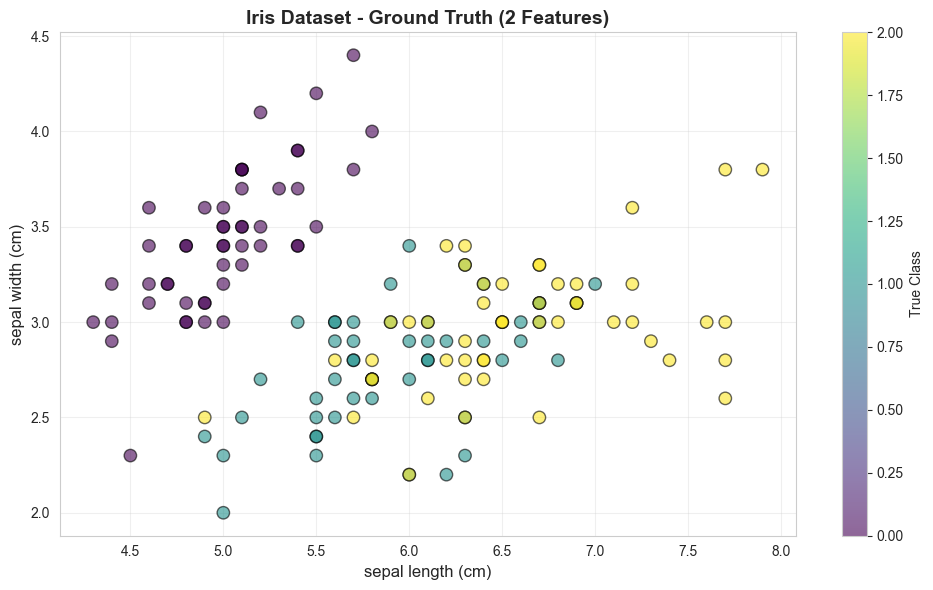

In [3]:
# Visualisasi data awal
plt.figure(figsize=(10, 6))
scatter = plt.scatter(X_iris[:, 0], X_iris[:, 1], c=y_iris_true, 
                     cmap='viridis', alpha=0.6, edgecolors='k', s=80)
plt.xlabel(feature_names[0], fontsize=12)
plt.ylabel(feature_names[1], fontsize=12)
plt.title('Iris Dataset - Ground Truth (2 Features)', fontsize=14, fontweight='bold')
plt.colorbar(scatter, label='True Class')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 2-3. Implementasi Elbow Method dan Plot

In [4]:
# Test berbagai nilai K
K_range = range(2, 11)
inertias = []
silhouette_scores = []

print("Implementasi Elbow Method (K = 2 sampai 10):")
for k in K_range:
    kmeans_temp = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans_temp.fit_predict(X_iris)
    
    inertias.append(kmeans_temp.inertia_)
    silhouette_scores.append(silhouette_score(X_iris, labels))
    print(f"K={k}: Inertia={kmeans_temp.inertia_:.2f}, Silhouette={silhouette_score(X_iris, labels):.4f}")

Implementasi Elbow Method (K = 2 sampai 10):


K=2: Inertia=58.20, Silhouette=0.4630
K=3: Inertia=37.05, Silhouette=0.4451
K=4: Inertia=27.99, Silhouette=0.4249
K=5: Inertia=21.00, Silhouette=0.4101
K=6: Inertia=17.41, Silhouette=0.3967
K=7: Inertia=14.83, Silhouette=0.4013
K=8: Inertia=12.84, Silhouette=0.3885
K=9: Inertia=11.24, Silhouette=0.3886
K=10: Inertia=9.66, Silhouette=0.3936


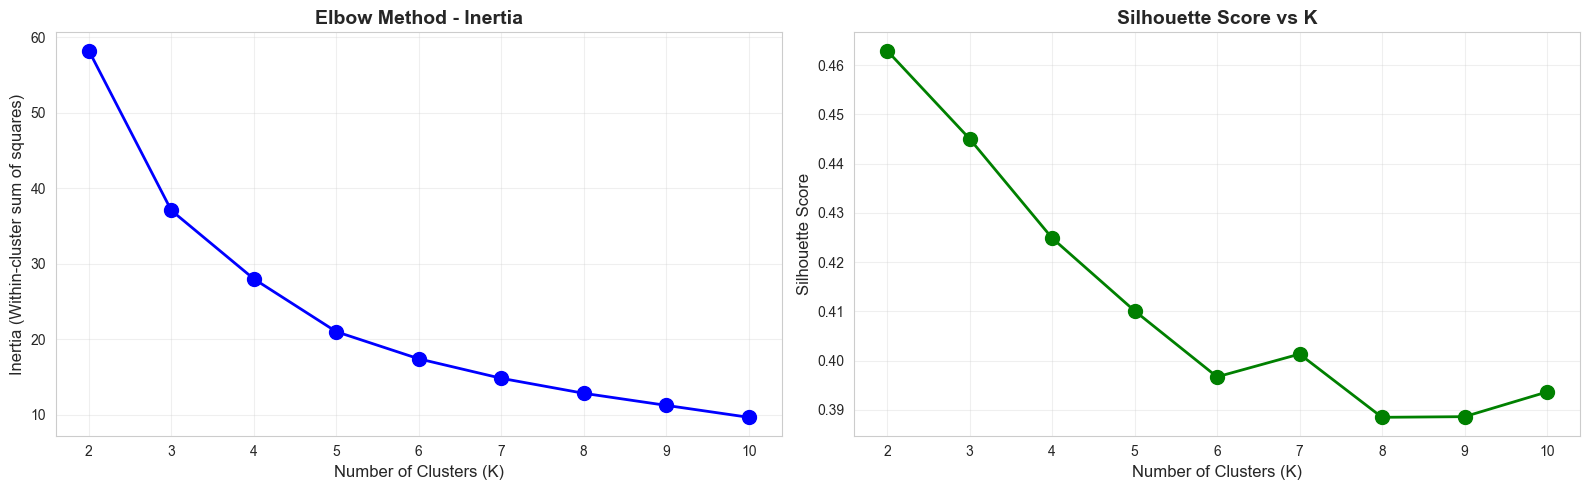

In [5]:
# Visualisasi Elbow Method
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Inertia plot
axes[0].plot(K_range, inertias, 'bo-', linewidth=2, markersize=10)
axes[0].set_xlabel('Number of Clusters (K)', fontsize=12)
axes[0].set_ylabel('Inertia (Within-cluster sum of squares)', fontsize=12)
axes[0].set_title('Elbow Method - Inertia', fontsize=14, fontweight='bold')
axes[0].grid(True, alpha=0.3)
axes[0].set_xticks(K_range)

# Silhouette Score plot
axes[1].plot(K_range, silhouette_scores, 'go-', linewidth=2, markersize=10)
axes[1].set_xlabel('Number of Clusters (K)', fontsize=12)
axes[1].set_ylabel('Silhouette Score', fontsize=12)
axes[1].set_title('Silhouette Score vs K', fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3)
axes[1].set_xticks(K_range)

plt.tight_layout()
plt.show()

### 4. Tentukan K Optimal

In [6]:
optimal_k_silhouette = K_range[np.argmax(silhouette_scores)]
print(f"Penentuan K Optimal:")
print(f"K optimal berdasarkan Silhouette Score: {optimal_k_silhouette}")
print(f"Silhouette Score maksimum: {max(silhouette_scores):.4f}")
print(f"Berdasarkan Elbow Method (visual): K=3 (titik elbow)")

Penentuan K Optimal:
K optimal berdasarkan Silhouette Score: 2
Silhouette Score maksimum: 0.4630
Berdasarkan Elbow Method (visual): K=3 (titik elbow)


### 5. Visualisasi Hasil Clustering

In [7]:
# K-Means dengan K optimal
optimal_k = 3
kmeans_iris = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
y_pred_iris = kmeans_iris.fit_predict(X_iris)

print(f"Hasil Clustering dengan K={optimal_k}:")
print(f"Inertia: {kmeans_iris.inertia_:.2f}")
print(f"Silhouette Score: {silhouette_score(X_iris, y_pred_iris):.4f}")
print(f"Davies-Bouldin Index: {davies_bouldin_score(X_iris, y_pred_iris):.4f}")

Hasil Clustering dengan K=3:
Inertia: 37.05
Silhouette Score: 0.4451
Davies-Bouldin Index: 0.7676


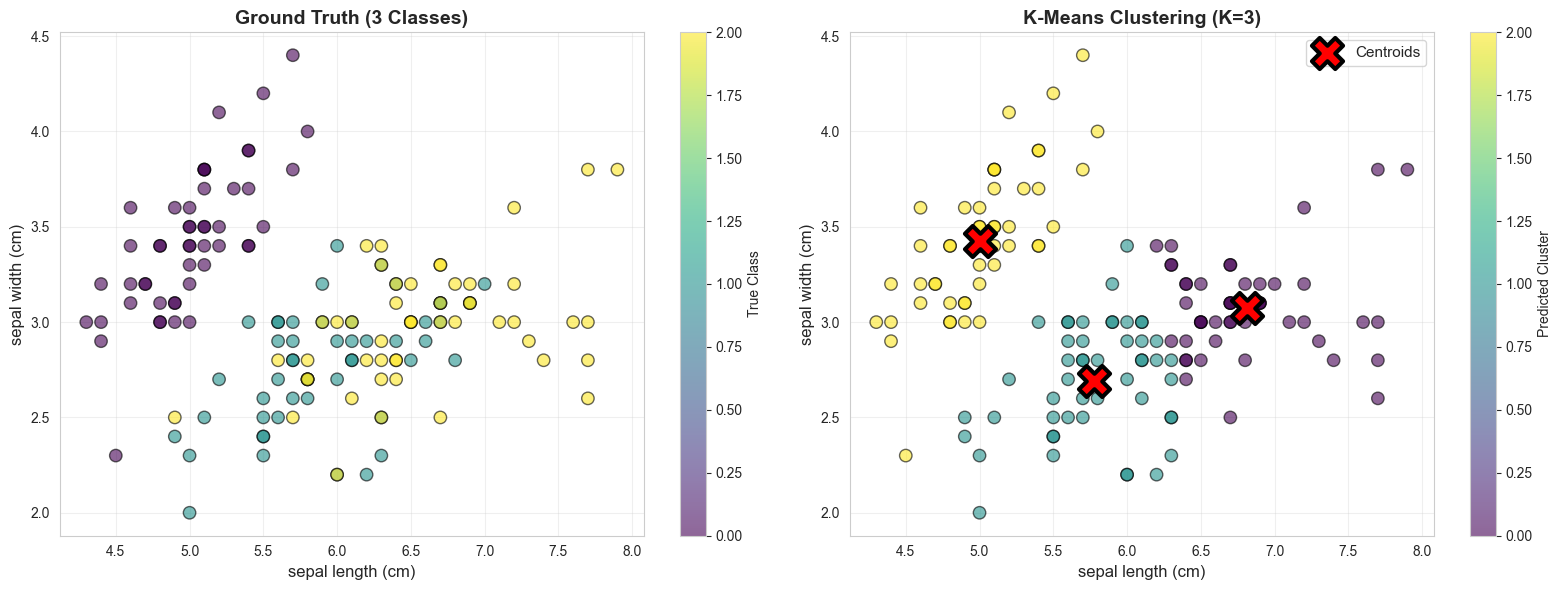

In [8]:
# Visualisasi hasil
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Ground Truth
scatter1 = axes[0].scatter(X_iris[:, 0], X_iris[:, 1], c=y_iris_true, 
                          cmap='viridis', alpha=0.6, edgecolors='k', s=80)
axes[0].set_xlabel(feature_names[0], fontsize=12)
axes[0].set_ylabel(feature_names[1], fontsize=12)
axes[0].set_title('Ground Truth (3 Classes)', fontsize=14, fontweight='bold')
axes[0].grid(True, alpha=0.3)
plt.colorbar(scatter1, ax=axes[0], label='True Class')

# K-Means Result
scatter2 = axes[1].scatter(X_iris[:, 0], X_iris[:, 1], c=y_pred_iris, 
                          cmap='viridis', alpha=0.6, edgecolors='k', s=80)
axes[1].scatter(kmeans_iris.cluster_centers_[:, 0], 
               kmeans_iris.cluster_centers_[:, 1],
               marker='X', s=500, c='red', edgecolors='black', linewidths=3,
               label='Centroids', zorder=5)
axes[1].set_xlabel(feature_names[0], fontsize=12)
axes[1].set_ylabel(feature_names[1], fontsize=12)
axes[1].set_title(f'K-Means Clustering (K={optimal_k})', fontsize=14, fontweight='bold')
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)
plt.colorbar(scatter2, ax=axes[1], label='Predicted Cluster')

plt.tight_layout()
plt.show()

### 6. Bandingkan dengan True Labels

In [9]:
print("Perbandingan dengan True Labels:")
print("Cluster Distribution:")
unique_clusters, cluster_counts = np.unique(y_pred_iris, return_counts=True)
for cluster, count in zip(unique_clusters, cluster_counts):
    print(f"Cluster {cluster}: {count} samples")

print("\nMapping Cluster ke True Class:")
for cluster_id in range(optimal_k):
    mask = y_pred_iris == cluster_id
    true_classes_in_cluster = y_iris_true[mask]
    unique_classes, counts = np.unique(true_classes_in_cluster, return_counts=True)
    print(f"Cluster {cluster_id}:")
    for cls, cnt in zip(unique_classes, counts):
        print(f"   Class {cls} ({iris.target_names[cls]}): {cnt} samples ({cnt/len(true_classes_in_cluster)*100:.1f}%)")

Perbandingan dengan True Labels:
Cluster Distribution:
Cluster 0: 47 samples
Cluster 1: 53 samples
Cluster 2: 50 samples

Mapping Cluster ke True Class:
Cluster 0:
   Class 1 (versicolor): 12 samples (25.5%)
   Class 2 (virginica): 35 samples (74.5%)
Cluster 1:
   Class 1 (versicolor): 38 samples (71.7%)
   Class 2 (virginica): 15 samples (28.3%)
Cluster 2:
   Class 0 (setosa): 50 samples (100.0%)


---
# TUGAS 2: HIERARCHICAL CLUSTERING (25 poin)
---

### 1-2. Compute Linkage Matrix dan Buat Dendrogram

In [10]:
# Gunakan dataset yang sama (Iris dengan 2 features)
X_hier = X_iris.copy()
y_hier_true = y_iris_true.copy()

print("Dataset yang digunakan: Iris (2 features)")
print(f"Shape: {X_hier.shape}")

Dataset yang digunakan: Iris (2 features)
Shape: (150, 2)


Membuat Dendrogram untuk setiap linkage method:
✓ Dendrogram single dibuat
✓ Dendrogram complete dibuat
✓ Dendrogram average dibuat
✓ Dendrogram ward dibuat


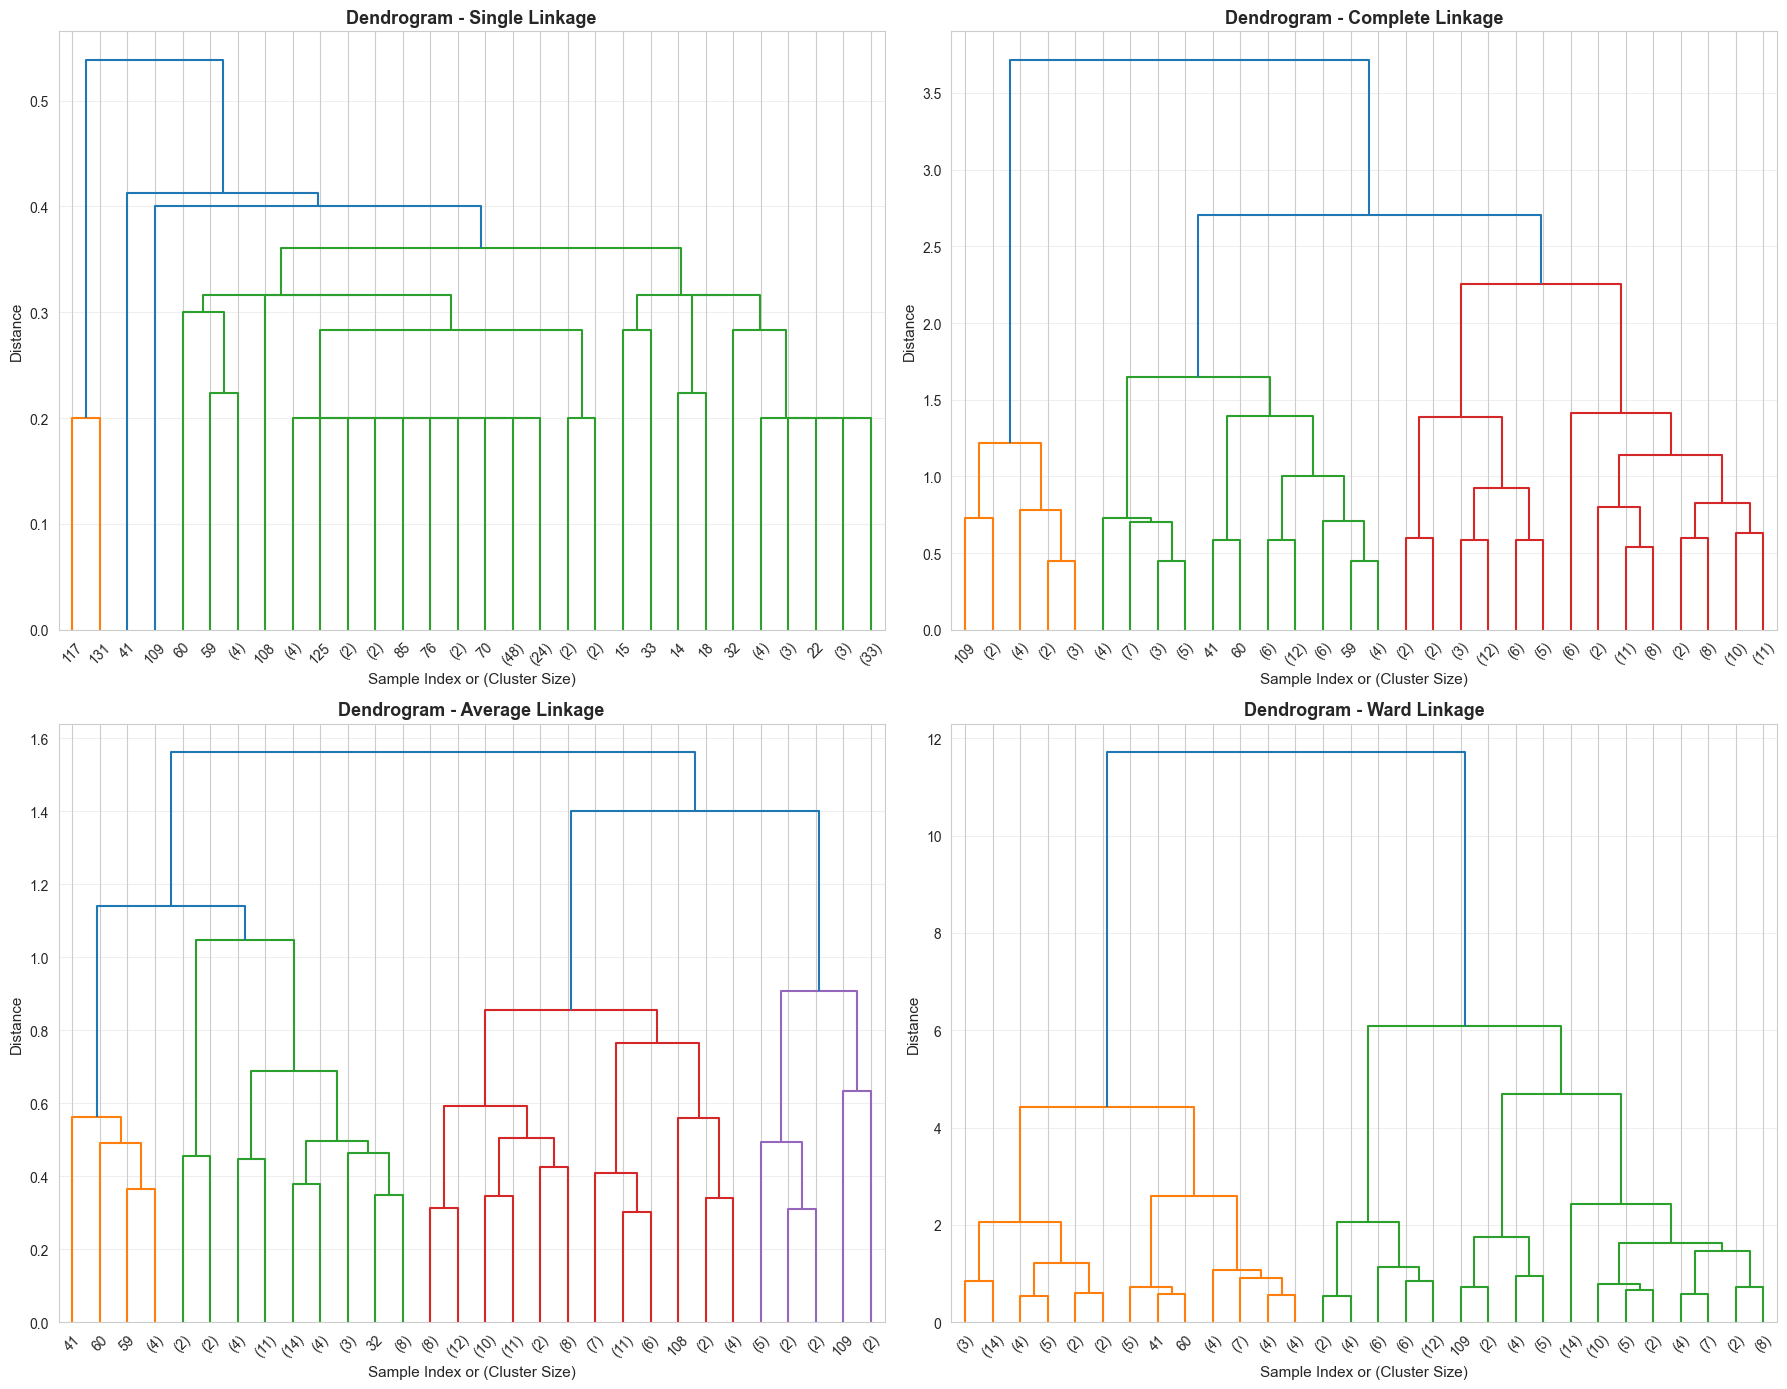

✓ Semua dendrogram selesai


In [11]:
# Membuat Dendrogram untuk setiap linkage method
linkage_methods = ['single', 'complete', 'average', 'ward']

fig, axes = plt.subplots(2, 2, figsize=(18, 14))

print("Membuat Dendrogram untuk setiap linkage method:")
for idx, method in enumerate(linkage_methods):
    row = idx // 2
    col = idx % 2
    
    # Compute linkage
    linkage_matrix = linkage(X_hier, method=method)
    
    # Plot dendrogram
    ax = axes[row, col]
    dendrogram(linkage_matrix, ax=ax, truncate_mode='lastp', p=30, 
              show_leaf_counts=True, leaf_font_size=10)
    ax.set_xlabel('Sample Index or (Cluster Size)', fontsize=11)
    ax.set_ylabel('Distance', fontsize=11)
    ax.set_title(f'Dendrogram - {method.capitalize()} Linkage', 
                fontsize=13, fontweight='bold')
    ax.grid(True, alpha=0.3, axis='y')
    
    print(f"✓ Dendrogram {method} dibuat")

plt.tight_layout()
plt.show()
print("✓ Semua dendrogram selesai")

### 3-4. Agglomerative Clustering dengan Berbagai n_clusters

In [12]:
n_clusters_range = [2, 3, 4, 5]
results_dict = {method: [] for method in linkage_methods}

print("Agglomerative Clustering dengan berbagai n_clusters:\n")
for method in linkage_methods:
    print(f"Linkage: {method}")
    for n_clust in n_clusters_range:
        agg = AgglomerativeClustering(n_clusters=n_clust, linkage=method)
        labels = agg.fit_predict(X_hier)
        sil_score = silhouette_score(X_hier, labels)
        db_score = davies_bouldin_score(X_hier, labels)
        
        results_dict[method].append({
            'n_clusters': n_clust,
            'silhouette': sil_score,
            'davies_bouldin': db_score
        })
        
        print(f"   n_clusters={n_clust}: Silhouette={sil_score:.4f}, Davies-Bouldin={db_score:.4f}")
    print()

Agglomerative Clustering dengan berbagai n_clusters:

Linkage: single
   n_clusters=2: Silhouette=0.4318, Davies-Bouldin=0.4332
   n_clusters=3: Silhouette=0.1321, Davies-Bouldin=0.5004
   n_clusters=4: Silhouette=0.0038, Davies-Bouldin=0.5126
   n_clusters=5: Silhouette=0.2331, Davies-Bouldin=0.5359

Linkage: complete
   n_clusters=2: Silhouette=0.3920, Davies-Bouldin=0.6663
   n_clusters=3: Silhouette=0.2023, Davies-Bouldin=1.2054
   n_clusters=4: Silhouette=0.3617, Davies-Bouldin=0.9205
   n_clusters=5: Silhouette=0.3996, Davies-Bouldin=0.7605

Linkage: average
   n_clusters=2: Silhouette=0.4777, Davies-Bouldin=0.7672
   n_clusters=3: Silhouette=0.4303, Davies-Bouldin=0.7381
   n_clusters=4: Silhouette=0.3767, Davies-Bouldin=0.6628
   n_clusters=5: Silhouette=0.3454, Davies-Bouldin=0.6360

Linkage: ward
   n_clusters=2: Silhouette=0.4777, Davies-Bouldin=0.7672
   n_clusters=3: Silhouette=0.3653, Davies-Bouldin=0.8019
   n_clusters=4: Silhouette=0.3823, Davies-Bouldin=0.7904
   n_clu

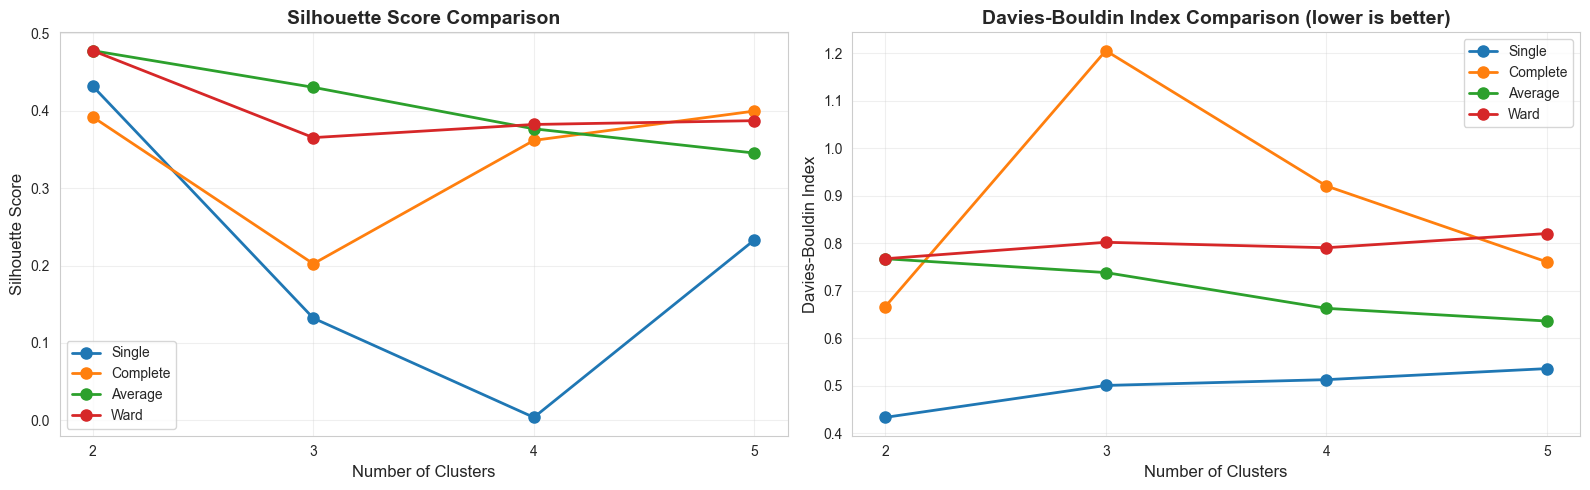

In [13]:
# Plot comparison
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for method in linkage_methods:
    silhouettes = [r['silhouette'] for r in results_dict[method]]
    davies_bouldins = [r['davies_bouldin'] for r in results_dict[method]]
    
    axes[0].plot(n_clusters_range, silhouettes, 'o-', linewidth=2, 
                markersize=8, label=method.capitalize())
    axes[1].plot(n_clusters_range, davies_bouldins, 'o-', linewidth=2, 
                markersize=8, label=method.capitalize())

axes[0].set_xlabel('Number of Clusters', fontsize=12)
axes[0].set_ylabel('Silhouette Score', fontsize=12)
axes[0].set_title('Silhouette Score Comparison', fontsize=14, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[0].set_xticks(n_clusters_range)

axes[1].set_xlabel('Number of Clusters', fontsize=12)
axes[1].set_ylabel('Davies-Bouldin Index', fontsize=12)
axes[1].set_title('Davies-Bouldin Index Comparison (lower is better)', 
                 fontsize=14, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)
axes[1].set_xticks(n_clusters_range)

plt.tight_layout()
plt.show()

### 5. Visualisasi Hasil untuk Setiap Linkage Method

Visualisasi hasil clustering untuk setiap linkage method:


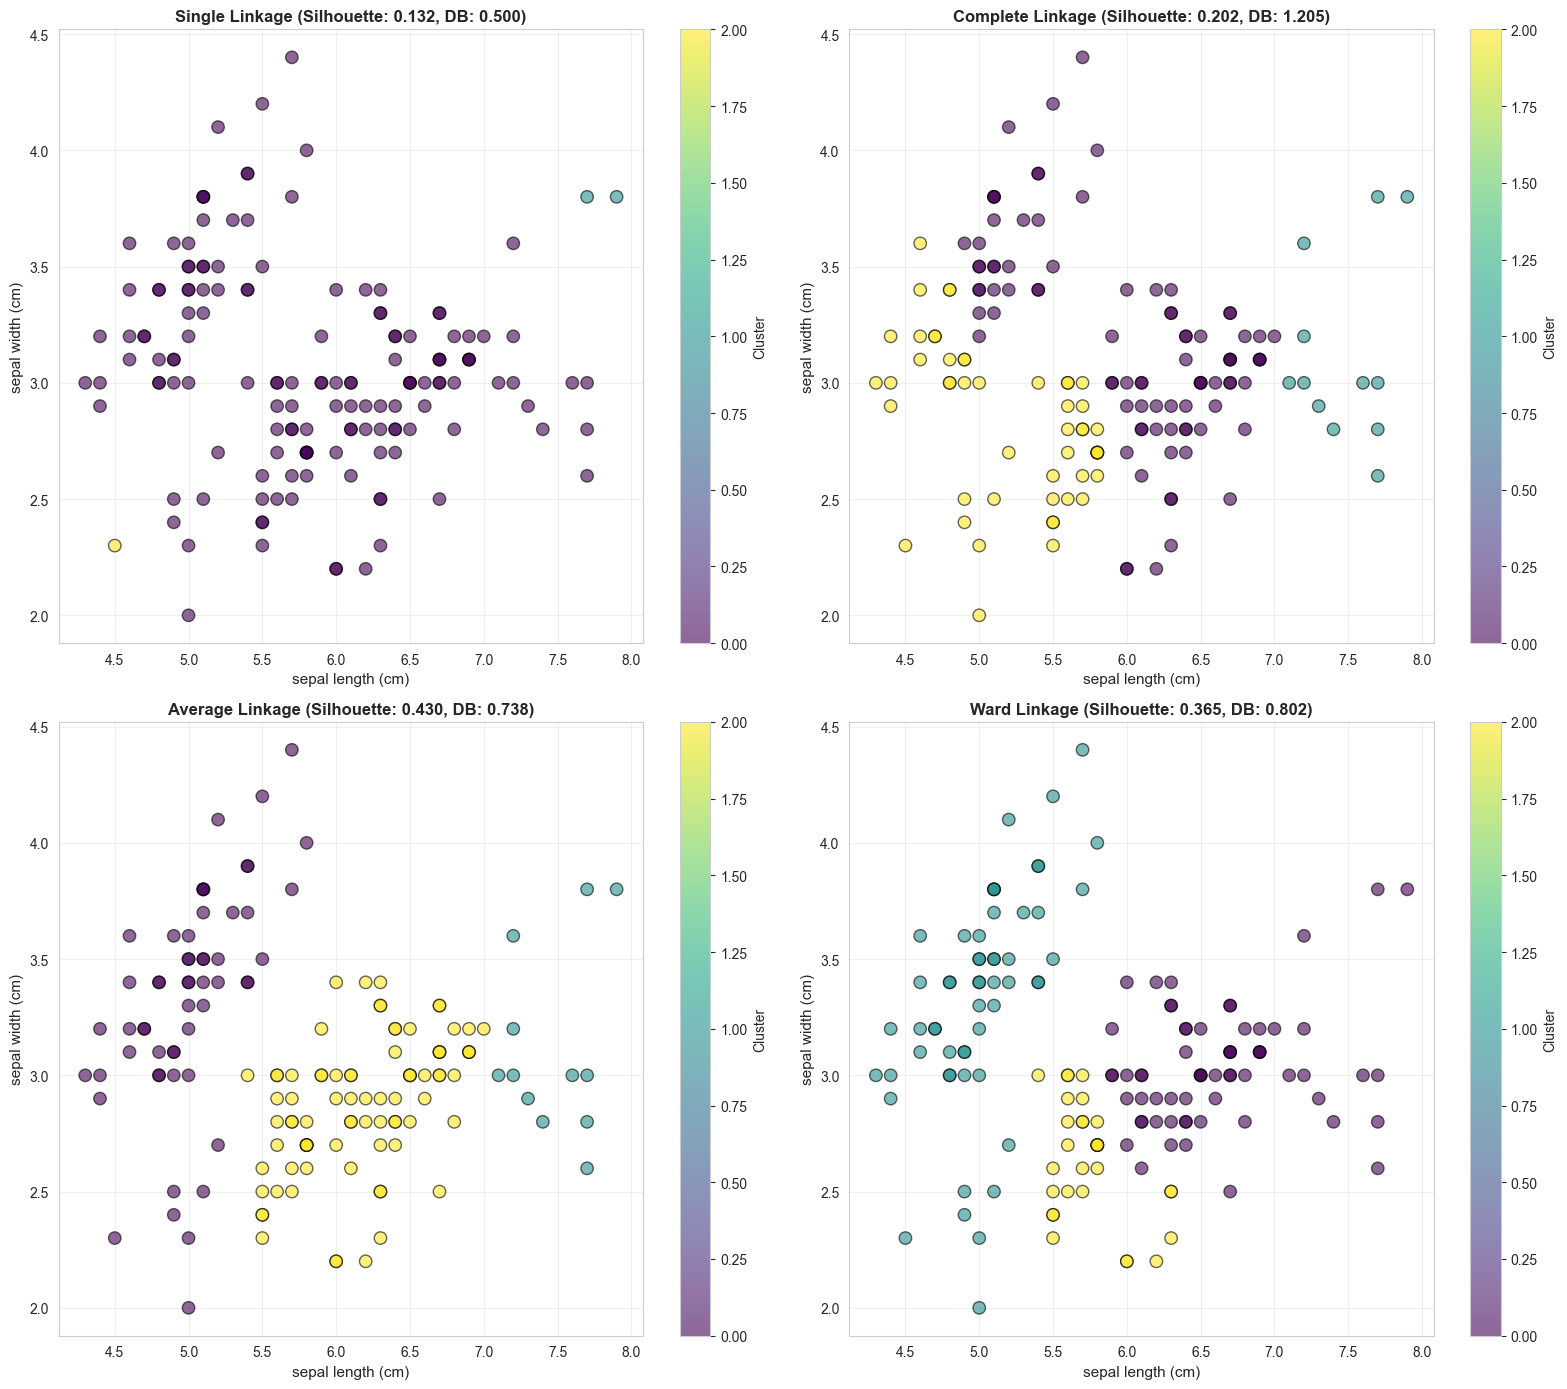

In [14]:
fig, axes = plt.subplots(2, 2, figsize=(16, 14))

print("Visualisasi hasil clustering untuk setiap linkage method:")
for idx, method in enumerate(linkage_methods):
    row = idx // 2
    col = idx % 2
    
    agg = AgglomerativeClustering(n_clusters=3, linkage=method)
    labels = agg.fit_predict(X_hier)
    sil_score = silhouette_score(X_hier, labels)
    db_score = davies_bouldin_score(X_hier, labels)
    
    scatter = axes[row, col].scatter(X_hier[:, 0], X_hier[:, 1], c=labels, 
                                     cmap='viridis', alpha=0.6, edgecolors='k', s=80)
    axes[row, col].set_xlabel(feature_names[0], fontsize=11)
    axes[row, col].set_ylabel(feature_names[1], fontsize=11)
    axes[row, col].set_title(
        f'{method.capitalize()} Linkage (Silhouette: {sil_score:.3f}, DB: {db_score:.3f})',
        fontsize=12, fontweight='bold')
    axes[row, col].grid(True, alpha=0.3)
    plt.colorbar(scatter, ax=axes[row, col], label='Cluster')

plt.tight_layout()
plt.show()

---
# TUGAS 3: K-MEANS VS HIERARCHICAL (25 poin)
---

### 1. Buat Dataset

In [15]:
# Buat dataset clustering yang lebih kompleks
X_compare, y_compare_true = make_blobs(
    n_samples=500,
    centers=4,
    n_features=2,
    cluster_std=0.8,
    random_state=42
)

print(f"Dataset shape: {X_compare.shape}")
print(f"Number of samples: {X_compare.shape[0]}")
print(f"Number of features: {X_compare.shape[1]}")
print(f"True number of clusters: 4")

Dataset shape: (500, 2)
Number of samples: 500
Number of features: 2
True number of clusters: 4


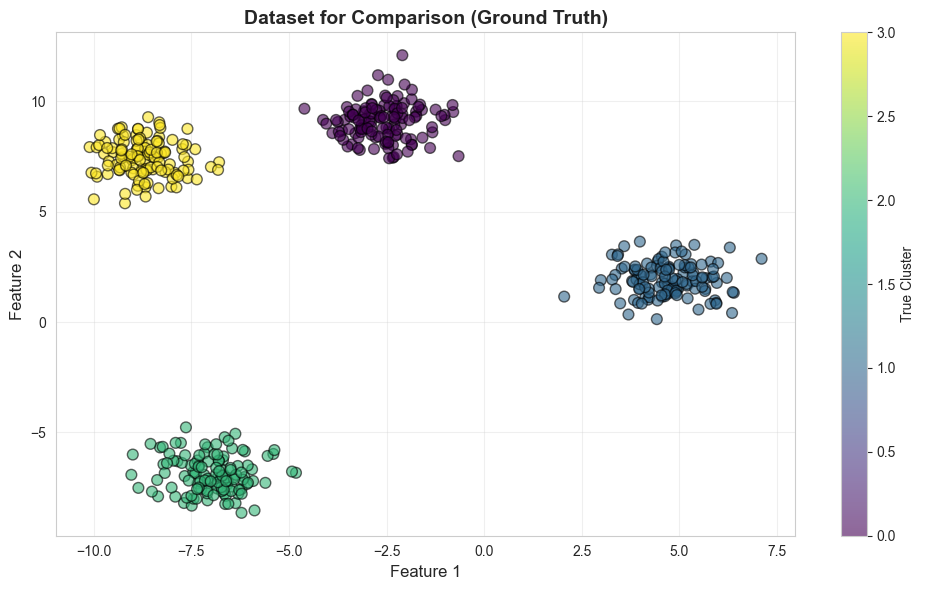

In [16]:
# Visualisasi dataset
plt.figure(figsize=(10, 6))
scatter = plt.scatter(X_compare[:, 0], X_compare[:, 1], c=y_compare_true,
                     cmap='viridis', alpha=0.6, edgecolors='k', s=60)
plt.xlabel('Feature 1', fontsize=12)
plt.ylabel('Feature 2', fontsize=12)
plt.title('Dataset for Comparison (Ground Truth)', fontsize=14, fontweight='bold')
plt.colorbar(scatter, label='True Cluster')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 2. Apply K-Means

In [17]:
print("Apply K-Means (K=4):")
start_time_kmeans = time.time()
kmeans_compare = KMeans(n_clusters=4, random_state=42, n_init=10)
labels_kmeans = kmeans_compare.fit_predict(X_compare)
time_kmeans = time.time() - start_time_kmeans

sil_kmeans = silhouette_score(X_compare, labels_kmeans)
db_kmeans = davies_bouldin_score(X_compare, labels_kmeans)

print(f"Silhouette Score: {sil_kmeans:.4f}")
print(f"Davies-Bouldin Index: {db_kmeans:.4f}")
print(f"Inertia: {kmeans_compare.inertia_:.2f}")
print(f"Computation Time: {time_kmeans:.4f} seconds")

Apply K-Means (K=4):
Silhouette Score: 0.8336
Davies-Bouldin Index: 0.2341
Inertia: 607.29
Computation Time: 0.0246 seconds


### 3. Apply Hierarchical Clustering

In [18]:
print("Apply Hierarchical Clustering (Ward linkage, n_clusters=4):")
start_time_hier = time.time()
hier_compare = AgglomerativeClustering(n_clusters=4, linkage='ward')
labels_hier = hier_compare.fit_predict(X_compare)
time_hier = time.time() - start_time_hier

sil_hier = silhouette_score(X_compare, labels_hier)
db_hier = davies_bouldin_score(X_compare, labels_hier)

print(f"Silhouette Score: {sil_hier:.4f}")
print(f"Davies-Bouldin Index: {db_hier:.4f}")
print(f"Computation Time: {time_hier:.4f} seconds")

Apply Hierarchical Clustering (Ward linkage, n_clusters=4):
Silhouette Score: 0.8336
Davies-Bouldin Index: 0.2341
Computation Time: 0.0090 seconds


### 4. Bandingkan

In [19]:
print("\nPERBANDINGAN K-MEANS VS HIERARCHICAL:")
print("="*80)

# Create comparison table
comparison_data = {
    'Metric': ['Silhouette Score', 'Davies-Bouldin Index', 'Computation Time (s)'],
    'K-Means': [f'{sil_kmeans:.4f}', f'{db_kmeans:.4f}', f'{time_kmeans:.4f}'],
    'Hierarchical (Ward)': [f'{sil_hier:.4f}', f'{db_hier:.4f}', f'{time_hier:.4f}'],
    'Winner': []
}

# Determine winners
if sil_kmeans > sil_hier:
    comparison_data['Winner'].append('K-Means')
else:
    comparison_data['Winner'].append('Hierarchical')

if db_kmeans < db_hier:
    comparison_data['Winner'].append('K-Means')
else:
    comparison_data['Winner'].append('Hierarchical')

if time_kmeans < time_hier:
    comparison_data['Winner'].append('K-Means')
else:
    comparison_data['Winner'].append('Hierarchical')

df_comparison = pd.DataFrame(comparison_data)
print("\n" + df_comparison.to_string(index=False))
print("\n" + "="*80)


PERBANDINGAN K-MEANS VS HIERARCHICAL:

              Metric K-Means Hierarchical (Ward)       Winner
    Silhouette Score  0.8336              0.8336 Hierarchical
Davies-Bouldin Index  0.2341              0.2341 Hierarchical
Computation Time (s)  0.0246              0.0090 Hierarchical



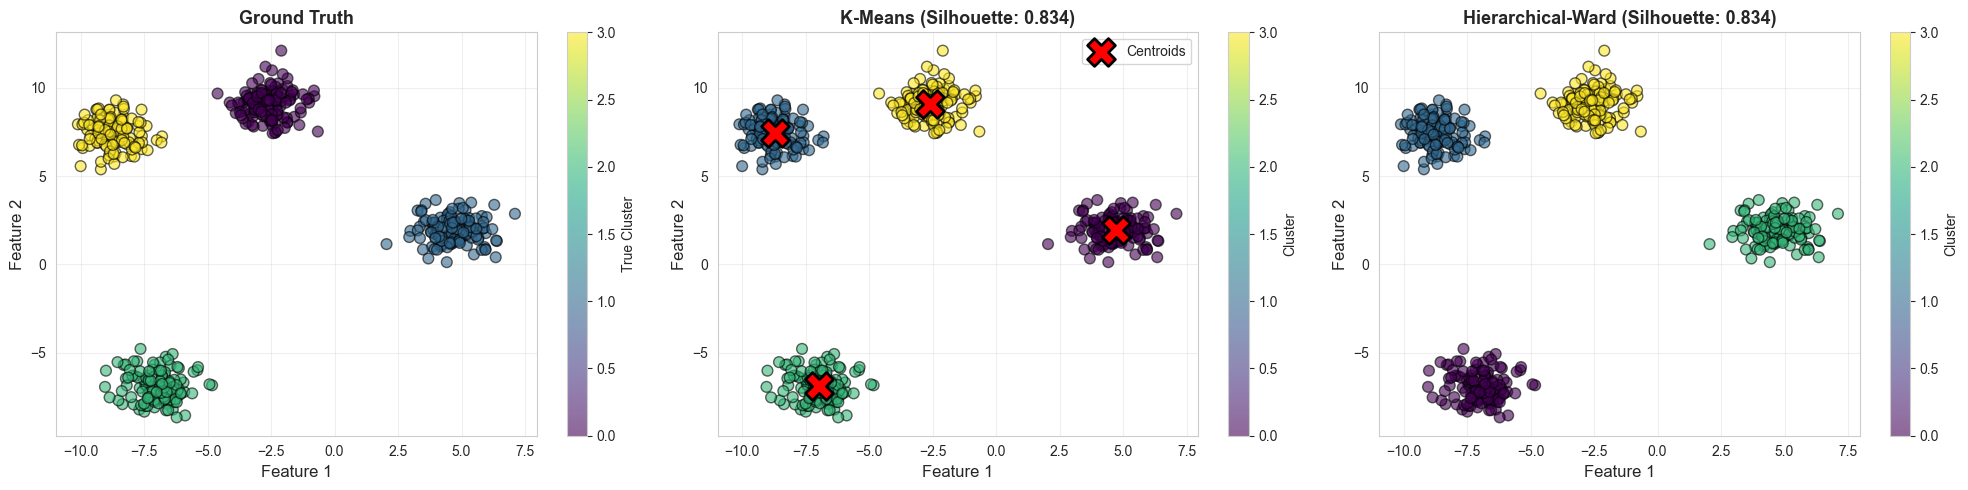

In [20]:
# Visualisasi cluster assignment
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# Ground Truth
scatter1 = axes[0].scatter(X_compare[:, 0], X_compare[:, 1], c=y_compare_true,
                          cmap='viridis', alpha=0.6, edgecolors='k', s=60)
axes[0].set_xlabel('Feature 1', fontsize=12)
axes[0].set_ylabel('Feature 2', fontsize=12)
axes[0].set_title('Ground Truth', fontsize=13, fontweight='bold')
axes[0].grid(True, alpha=0.3)
plt.colorbar(scatter1, ax=axes[0], label='True Cluster')

# K-Means
scatter2 = axes[1].scatter(X_compare[:, 0], X_compare[:, 1], c=labels_kmeans,
                          cmap='viridis', alpha=0.6, edgecolors='k', s=60)
axes[1].scatter(kmeans_compare.cluster_centers_[:, 0],
               kmeans_compare.cluster_centers_[:, 1],
               marker='X', s=400, c='red', edgecolors='black', linewidths=2,
               label='Centroids', zorder=5)
axes[1].set_xlabel('Feature 1', fontsize=12)
axes[1].set_ylabel('Feature 2', fontsize=12)
axes[1].set_title(f'K-Means (Silhouette: {sil_kmeans:.3f})', 
                 fontsize=13, fontweight='bold')
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)
plt.colorbar(scatter2, ax=axes[1], label='Cluster')

# Hierarchical
scatter3 = axes[2].scatter(X_compare[:, 0], X_compare[:, 1], c=labels_hier,
                          cmap='viridis', alpha=0.6, edgecolors='k', s=60)
axes[2].set_xlabel('Feature 1', fontsize=12)
axes[2].set_ylabel('Feature 2', fontsize=12)
axes[2].set_title(f'Hierarchical-Ward (Silhouette: {sil_hier:.3f})', 
                 fontsize=13, fontweight='bold')
axes[2].grid(True, alpha=0.3)
plt.colorbar(scatter3, ax=axes[2], label='Cluster')

plt.tight_layout()
plt.show()

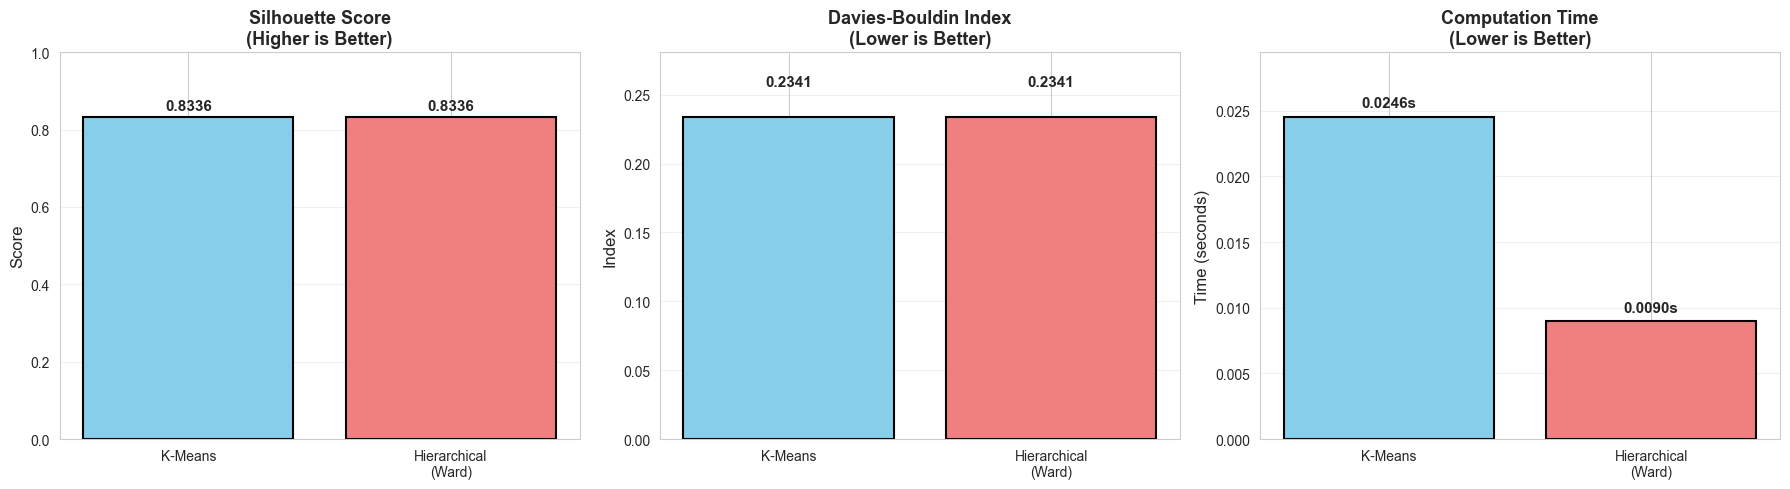

In [21]:
# Metrics comparison plot
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Silhouette Score
methods = ['K-Means', 'Hierarchical\n(Ward)']
sil_scores = [sil_kmeans, sil_hier]
bars1 = axes[0].bar(methods, sil_scores, color=['skyblue', 'lightcoral'], 
                    edgecolor='black', linewidth=1.5)
axes[0].set_ylabel('Score', fontsize=12)
axes[0].set_title('Silhouette Score\n(Higher is Better)', fontsize=13, fontweight='bold')
axes[0].set_ylim([0, max(sil_scores) * 1.2])
axes[0].grid(True, alpha=0.3, axis='y')
for bar, score in zip(bars1, sil_scores):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{score:.4f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

# Davies-Bouldin Index
db_scores = [db_kmeans, db_hier]
bars2 = axes[1].bar(methods, db_scores, color=['skyblue', 'lightcoral'],
                    edgecolor='black', linewidth=1.5)
axes[1].set_ylabel('Index', fontsize=12)
axes[1].set_title('Davies-Bouldin Index\n(Lower is Better)', fontsize=13, fontweight='bold')
axes[1].set_ylim([0, max(db_scores) * 1.2])
axes[1].grid(True, alpha=0.3, axis='y')
for bar, score in zip(bars2, db_scores):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                f'{score:.4f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

# Computation Time
times = [time_kmeans, time_hier]
bars3 = axes[2].bar(methods, times, color=['skyblue', 'lightcoral'],
                    edgecolor='black', linewidth=1.5)
axes[2].set_ylabel('Time (seconds)', fontsize=12)
axes[2].set_title('Computation Time\n(Lower is Better)', fontsize=13, fontweight='bold')
axes[2].set_ylim([0, max(times) * 1.2])
axes[2].grid(True, alpha=0.3, axis='y')
for bar, t in zip(bars3, times):
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(times)*0.02,
                f'{t:.4f}s', ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

---
# TUGAS 4: CUSTOMER SEGMENTATION PROJECT (25 poin)
---

### 1. Generate Mall Customer Dataset

In [22]:
# Generate Mall Customer Dataset
np.random.seed(42)
n_customers = 500

# Generate customer data with realistic patterns
age_groups = []
income_groups = []
spending_groups = []
visits_groups = []

# Segment 1: Young High Earners, High Spenders (25%)
n1 = 125
age_groups.append(np.random.randint(22, 35, n1))
income_groups.append(np.random.randint(70000, 120000, n1))
spending_groups.append(np.random.randint(70, 99, n1))
visits_groups.append(np.random.randint(15, 30, n1))

# Segment 2: Middle Age, Medium Income, Medium Spenders (30%)
n2 = 150
age_groups.append(np.random.randint(35, 50, n2))
income_groups.append(np.random.randint(40000, 70000, n2))
spending_groups.append(np.random.randint(40, 70, n2))
visits_groups.append(np.random.randint(8, 18, n2))

# Segment 3: Older, Low-Medium Income, Low Spenders (25%)
n3 = 125
age_groups.append(np.random.randint(50, 70, n3))
income_groups.append(np.random.randint(25000, 50000, n3))
spending_groups.append(np.random.randint(15, 45, n3))
visits_groups.append(np.random.randint(2, 10, n3))

# Segment 4: Young, Low Income, Low Spenders (20%)
n4 = 100
age_groups.append(np.random.randint(18, 30, n4))
income_groups.append(np.random.randint(20000, 40000, n4))
spending_groups.append(np.random.randint(10, 40, n4))
visits_groups.append(np.random.randint(3, 12, n4))

# Combine all segments
mall_customer_data = pd.DataFrame({
    'CustomerID': range(1, n_customers + 1),
    'Age': np.concatenate(age_groups),
    'Annual_Income': np.concatenate(income_groups),
    'Spending_Score': np.concatenate(spending_groups),
    'Visits_per_Month': np.concatenate(visits_groups)
})

# Shuffle the data
mall_customer_data = mall_customer_data.sample(frac=1, random_state=42).reset_index(drop=True)

print(f"✓ Dataset created with {len(mall_customer_data)} customers")
print(f"✓ Features: {list(mall_customer_data.columns)}")

# Save dataset
mall_customer_data.to_csv('mall_customer_segmentation_dataset.csv', index=False)
print(f"✓ Dataset saved as CSV")

✓ Dataset created with 500 customers
✓ Features: ['CustomerID', 'Age', 'Annual_Income', 'Spending_Score', 'Visits_per_Month']
✓ Dataset saved as CSV


In [23]:
print("\nDataset Preview:")
print(mall_customer_data.head(10))

print("\nDataset Statistics:")
print(mall_customer_data.describe())


Dataset Preview:
   CustomerID  Age  Annual_Income  Spending_Score  Visits_per_Month
0         362   63          39755              43                 6
1          74   23         110294              72                23
2         375   57          49777              17                 3
3         156   49          62301              54                16
4         105   34         108623              96                20
5         395   56          38490              37                 6
6         378   55          29212              38                 3
7         125   32          85087              74                17
8          69   34         100080              77                22
9         451   29          21165              22                 6

Dataset Statistics:
       CustomerID         Age  Annual_Income  Spending_Score  Visits_per_Month
count  500.000000  500.000000     500.000000      500.000000        500.000000
mean   250.500000   39.004000   55650.878000       49.7

### 2. EDA: Distribusi Features dan Correlation

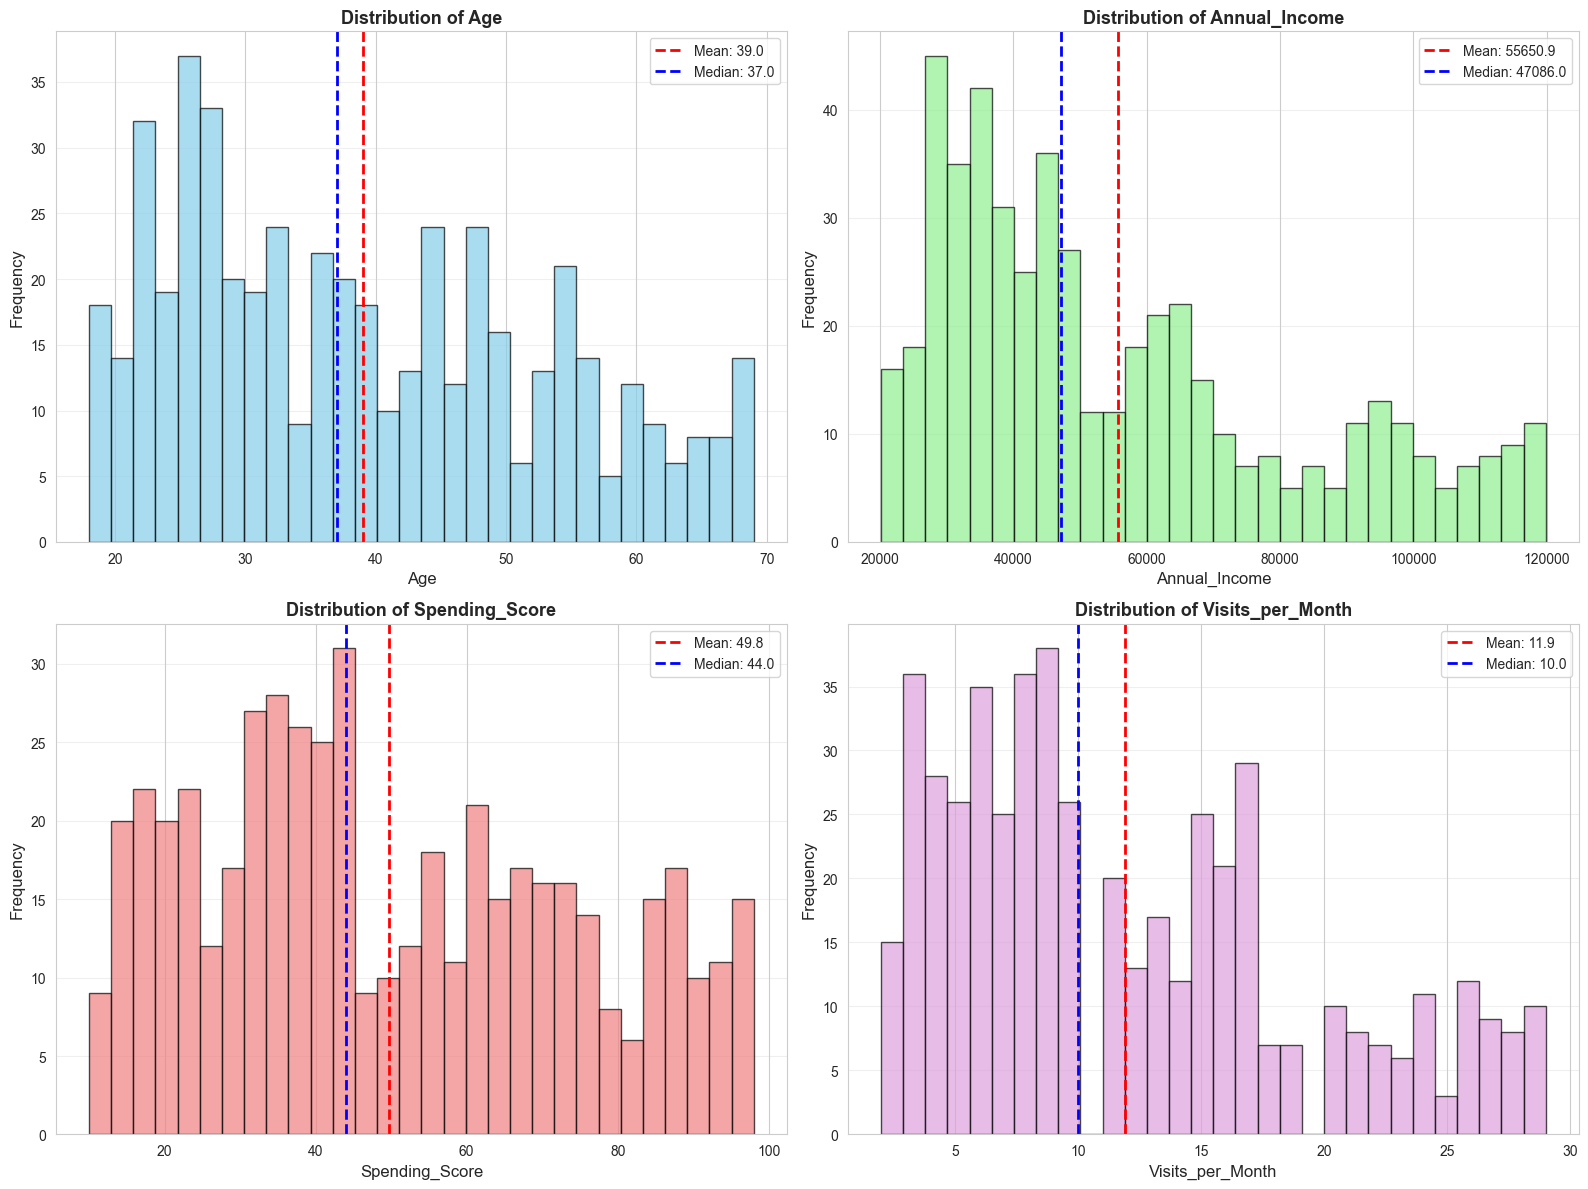

In [24]:
# Distribution plots
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

features = ['Age', 'Annual_Income', 'Spending_Score', 'Visits_per_Month']
colors = ['skyblue', 'lightgreen', 'lightcoral', 'plum']

for idx, (feature, color) in enumerate(zip(features, colors)):
    row = idx // 2
    col = idx % 2
    
    axes[row, col].hist(mall_customer_data[feature], bins=30, color=color, 
                       edgecolor='black', alpha=0.7)
    axes[row, col].set_xlabel(feature, fontsize=12)
    axes[row, col].set_ylabel('Frequency', fontsize=12)
    axes[row, col].set_title(f'Distribution of {feature}', fontsize=13, fontweight='bold')
    axes[row, col].grid(True, alpha=0.3, axis='y')
    
    # Add statistics
    mean_val = mall_customer_data[feature].mean()
    median_val = mall_customer_data[feature].median()
    axes[row, col].axvline(mean_val, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_val:.1f}')
    axes[row, col].axvline(median_val, color='blue', linestyle='--', linewidth=2, label=f'Median: {median_val:.1f}')
    axes[row, col].legend()

plt.tight_layout()
plt.show()

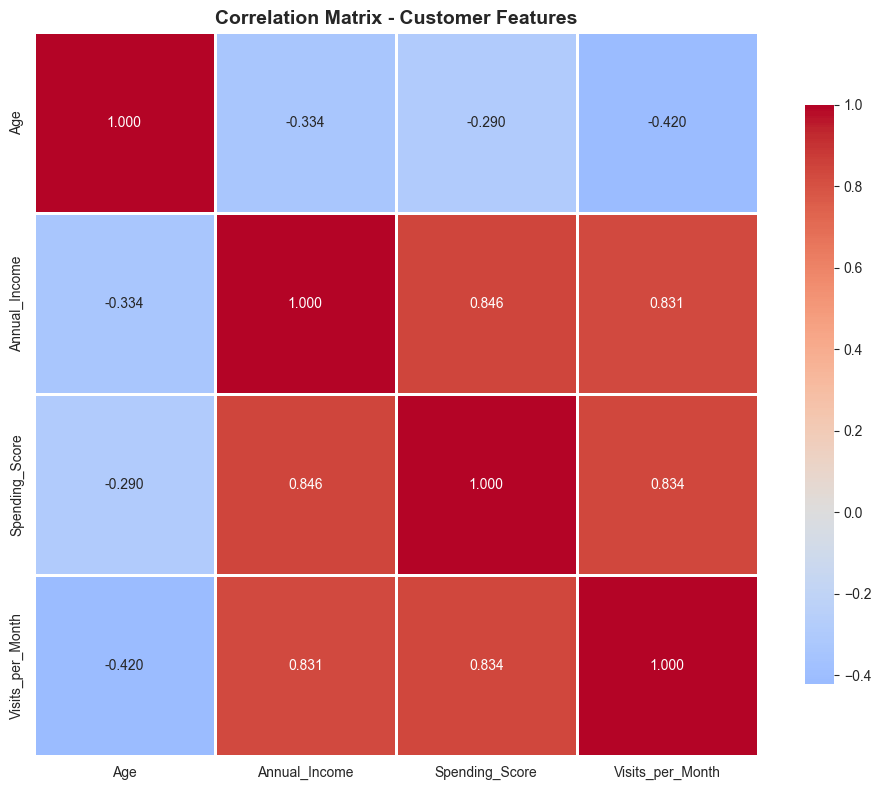


Correlation Insights:
• Age vs Annual_Income: -0.334 (Moderate)
• Age vs Visits_per_Month: -0.420 (Moderate)
• Annual_Income vs Spending_Score: 0.846 (Strong)
• Annual_Income vs Visits_per_Month: 0.831 (Strong)
• Spending_Score vs Visits_per_Month: 0.834 (Strong)


In [25]:
# Correlation matrix
correlation_matrix = mall_customer_data[features].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, fmt='.3f', cmap='coolwarm', 
           center=0, square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Correlation Matrix - Customer Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\nCorrelation Insights:")
for i in range(len(features)):
    for j in range(i+1, len(features)):
        corr_val = correlation_matrix.iloc[i, j]
        if abs(corr_val) > 0.5:
            print(f"• {features[i]} vs {features[j]}: {corr_val:.3f} (Strong)")
        elif abs(corr_val) > 0.3:
            print(f"• {features[i]} vs {features[j]}: {corr_val:.3f} (Moderate)")

Creating pairplot for feature relationships...


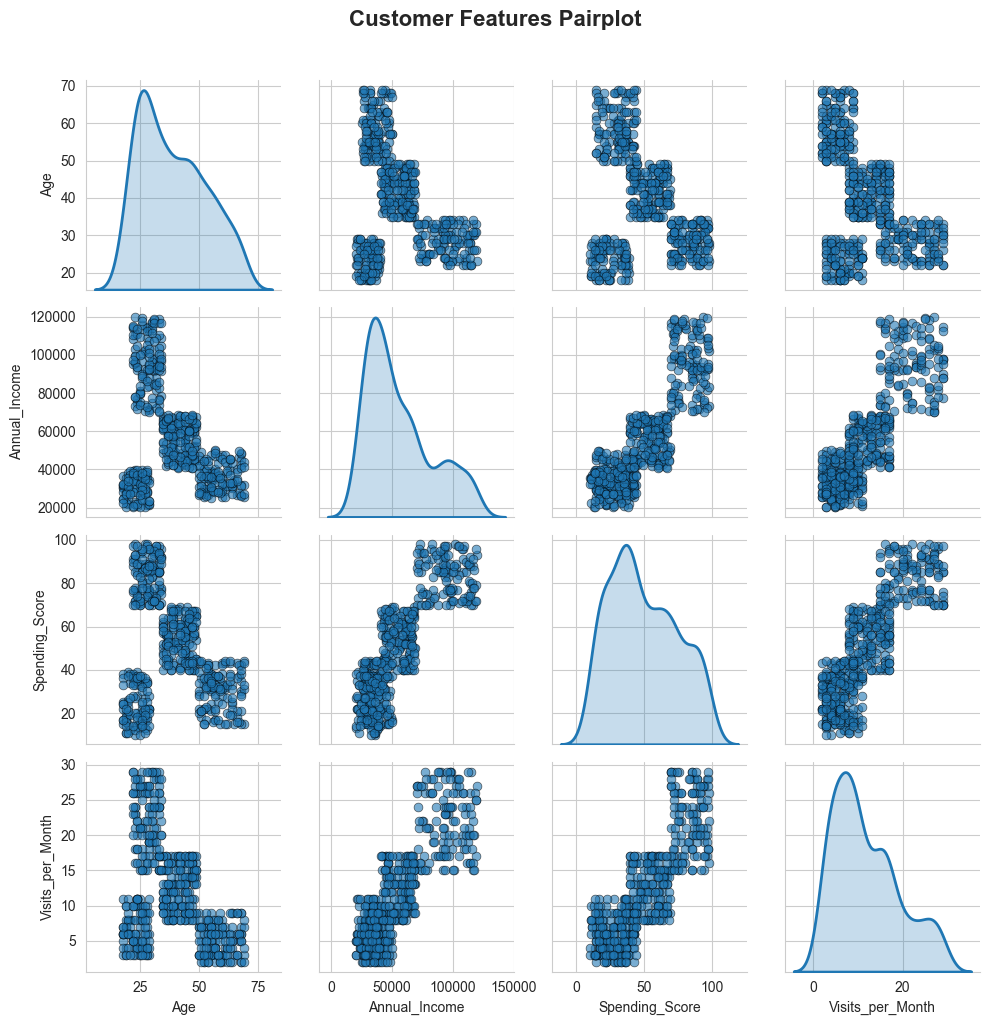

In [26]:
# Pairplot
print("Creating pairplot for feature relationships...")
pairplot_fig = sns.pairplot(mall_customer_data[features], diag_kind='kde', 
                            plot_kws={'alpha': 0.6, 's': 40, 'edgecolor': 'k'},
                            diag_kws={'linewidth': 2})
pairplot_fig.fig.suptitle('Customer Features Pairplot', y=1.02, fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

### 3. Feature Engineering

In [27]:
# Create additional features
mall_customer_data['Income_per_Age'] = mall_customer_data['Annual_Income'] / mall_customer_data['Age']
mall_customer_data['Spending_per_Visit'] = mall_customer_data['Spending_Score'] / mall_customer_data['Visits_per_Month']
mall_customer_data['Value_Index'] = (mall_customer_data['Spending_Score'] * mall_customer_data['Visits_per_Month']) / 100

print("✓ New features created:")
print("   • Income_per_Age: Annual Income / Age")
print("   • Spending_per_Visit: Spending Score / Visits per Month")
print("   • Value_Index: (Spending Score × Visits) / 100")

# Select features for clustering
features_for_clustering = ['Age', 'Annual_Income', 'Spending_Score', 'Visits_per_Month']
X_customer = mall_customer_data[features_for_clustering].values

print(f"\nFeatures used for clustering: {features_for_clustering}")

✓ New features created:
   • Income_per_Age: Annual Income / Age
   • Spending_per_Visit: Spending Score / Visits per Month
   • Value_Index: (Spending Score × Visits) / 100

Features used for clustering: ['Age', 'Annual_Income', 'Spending_Score', 'Visits_per_Month']


### 4. Standardize Features

In [28]:
scaler = StandardScaler()
X_customer_scaled = scaler.fit_transform(X_customer)

print("✓ Features standardized using StandardScaler")
print("\nStandardization Statistics:")
print(f"Mean (should be ~0): {X_customer_scaled.mean(axis=0)}")
print(f"Std (should be ~1): {X_customer_scaled.std(axis=0)}")

✓ Features standardized using StandardScaler

Standardization Statistics:
Mean (should be ~0): [ 1.56319402e-16  1.13686838e-16 -1.27897692e-16  9.23705556e-17]
Std (should be ~1): [1. 1. 1. 1.]


### 5. Determine Optimal K

In [29]:
K_range_customer = range(2, 11)
inertias_customer = []
silhouettes_customer = []
davies_bouldin_customer = []

print("DETERMINING OPTIMAL K:")
print("="*80)
for k in K_range_customer:
    kmeans_temp = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels_temp = kmeans_temp.fit_predict(X_customer_scaled)
    
    inertias_customer.append(kmeans_temp.inertia_)
    silhouettes_customer.append(silhouette_score(X_customer_scaled, labels_temp))
    davies_bouldin_customer.append(davies_bouldin_score(X_customer_scaled, labels_temp))
    
    print(f"K={k}: Inertia={kmeans_temp.inertia_:.2f}, "
          f"Silhouette={silhouette_score(X_customer_scaled, labels_temp):.4f}, "
          f"Davies-Bouldin={davies_bouldin_score(X_customer_scaled, labels_temp):.4f}")

DETERMINING OPTIMAL K:
K=2: Inertia=886.02, Silhouette=0.5090, Davies-Bouldin=0.6805
K=3: Inertia=548.05, Silhouette=0.4881, Davies-Bouldin=0.7478
K=4: Inertia=278.61, Silhouette=0.5589, Davies-Bouldin=0.6385
K=5: Inertia=242.70, Silhouette=0.4958, Davies-Bouldin=0.9283
K=6: Inertia=222.30, Silhouette=0.4023, Davies-Bouldin=1.1874
K=7: Inertia=205.54, Silhouette=0.3966, Davies-Bouldin=1.1402
K=8: Inertia=189.30, Silhouette=0.3261, Davies-Bouldin=1.2979
K=9: Inertia=181.04, Silhouette=0.3232, Davies-Bouldin=1.2550
K=10: Inertia=169.24, Silhouette=0.2515, Davies-Bouldin=1.4421


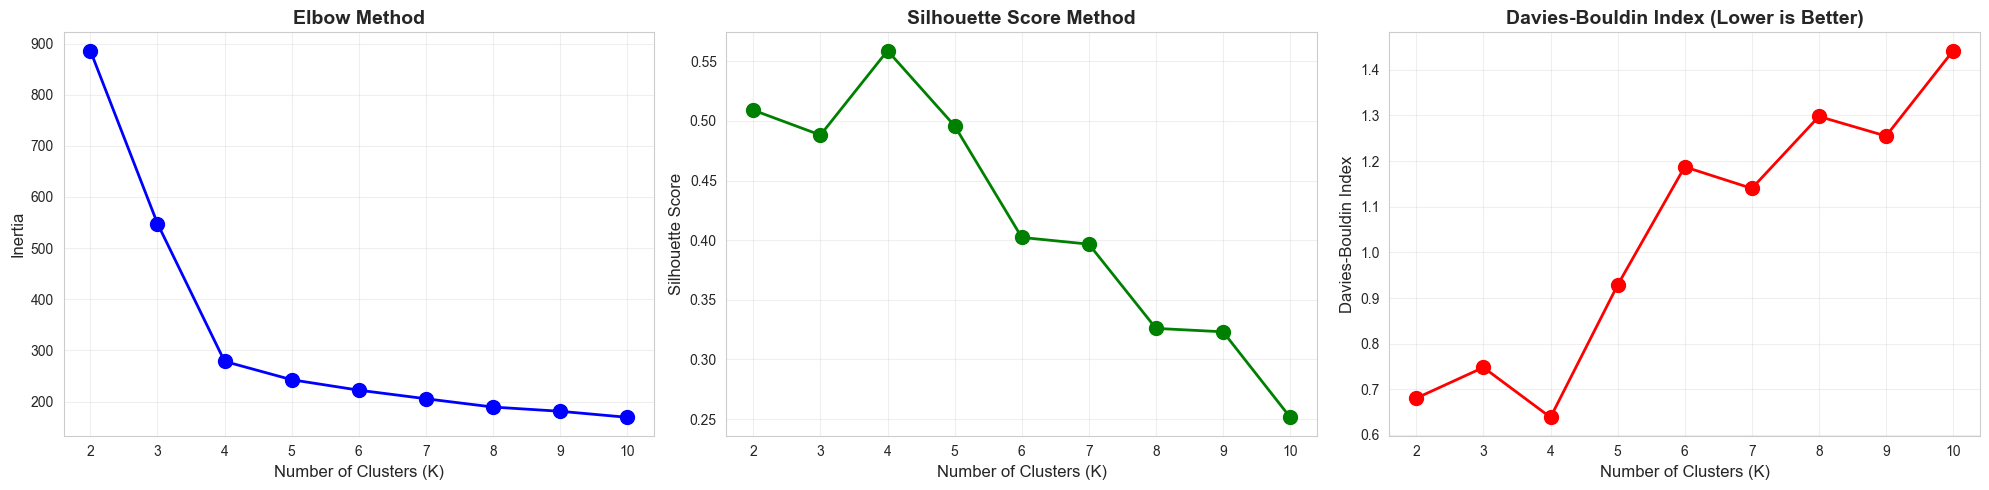

In [30]:
# Plot multiple methods
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# Elbow Method
axes[0].plot(K_range_customer, inertias_customer, 'bo-', linewidth=2, markersize=10)
axes[0].set_xlabel('Number of Clusters (K)', fontsize=12)
axes[0].set_ylabel('Inertia', fontsize=12)
axes[0].set_title('Elbow Method', fontsize=14, fontweight='bold')
axes[0].grid(True, alpha=0.3)
axes[0].set_xticks(K_range_customer)

# Silhouette Score
axes[1].plot(K_range_customer, silhouettes_customer, 'go-', linewidth=2, markersize=10)
axes[1].set_xlabel('Number of Clusters (K)', fontsize=12)
axes[1].set_ylabel('Silhouette Score', fontsize=12)
axes[1].set_title('Silhouette Score Method', fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3)
axes[1].set_xticks(K_range_customer)

# Davies-Bouldin Index
axes[2].plot(K_range_customer, davies_bouldin_customer, 'ro-', linewidth=2, markersize=10)
axes[2].set_xlabel('Number of Clusters (K)', fontsize=12)
axes[2].set_ylabel('Davies-Bouldin Index', fontsize=12)
axes[2].set_title('Davies-Bouldin Index (Lower is Better)', fontsize=14, fontweight='bold')
axes[2].grid(True, alpha=0.3)
axes[2].set_xticks(K_range_customer)

plt.tight_layout()
plt.show()

In [31]:
# Determine optimal K
optimal_k_customer = K_range_customer[np.argmax(silhouettes_customer)]
print(f"\nOPTIMAL K DETERMINATION:")
print(f"• Silhouette Score suggests K = {optimal_k_customer}")
print(f"• Elbow Method suggests K = 4 (visual inspection)")
print(f"• Davies-Bouldin suggests K = {K_range_customer[np.argmin(davies_bouldin_customer)]}")
print(f"\nFINAL CHOICE: K = 4 (balanced across all methods)")


OPTIMAL K DETERMINATION:
• Silhouette Score suggests K = 4
• Elbow Method suggests K = 4 (visual inspection)
• Davies-Bouldin suggests K = 4

FINAL CHOICE: K = 4 (balanced across all methods)


### 6. Apply Clustering

In [32]:
optimal_k_final = 4
print(f"APPLYING K-MEANS CLUSTERING (K={optimal_k_final}):")
print("="*80)

kmeans_final_customer = KMeans(n_clusters=optimal_k_final, random_state=42, n_init=10)
mall_customer_data['Segment'] = kmeans_final_customer.fit_predict(X_customer_scaled)

final_silhouette = silhouette_score(X_customer_scaled, mall_customer_data['Segment'])
final_davies_bouldin = davies_bouldin_score(X_customer_scaled, mall_customer_data['Segment'])

print(f"✓ Clustering completed")
print(f"Silhouette Score: {final_silhouette:.4f}")
print(f"Davies-Bouldin Index: {final_davies_bouldin:.4f}")
print(f"Inertia: {kmeans_final_customer.inertia_:.2f}")

APPLYING K-MEANS CLUSTERING (K=4):
✓ Clustering completed
Silhouette Score: 0.5589
Davies-Bouldin Index: 0.6385
Inertia: 278.61


### 7. Profiling Setiap Segment

In [33]:
print("\nCUSTOMER SEGMENT PROFILING:")
print("="*80)

for segment in range(optimal_k_final):
    segment_data = mall_customer_data[mall_customer_data['Segment'] == segment]
    
    print(f"\nSEGMENT {segment}:")
    print("-" * 80)
    print(f"Size: {len(segment_data)} customers ({len(segment_data)/len(mall_customer_data)*100:.1f}%)")
    print(f"")
    print(f"Profile:")
    for feature in features_for_clustering:
        mean_val = segment_data[feature].mean()
        median_val = segment_data[feature].median()
        std_val = segment_data[feature].std()
        print(f"   • {feature:20s}: Mean={mean_val:8.1f}, Median={median_val:8.1f}, Std={std_val:6.1f}")


CUSTOMER SEGMENT PROFILING:

SEGMENT 0:
--------------------------------------------------------------------------------
Size: 124 customers (24.8%)

Profile:
   • Age                 : Mean=    28.4, Median=    29.0, Std=   3.7
   • Annual_Income       : Mean= 95622.0, Median= 95692.5, Std=14484.5
   • Spending_Score      : Mean=    83.6, Median=    85.0, Std=   8.9
   • Visits_per_Month    : Mean=    22.1, Median=    22.0, Std=   4.5

SEGMENT 1:
--------------------------------------------------------------------------------
Size: 151 customers (30.2%)

Profile:
   • Age                 : Mean=    41.9, Median=    42.0, Std=   4.5
   • Annual_Income       : Mean= 55622.4, Median= 57101.0, Std=8830.8
   • Spending_Score      : Mean=    54.8, Median=    56.0, Std=   8.8
   • Visits_per_Month    : Mean=    12.6, Median=    13.0, Std=   3.0

SEGMENT 2:
--------------------------------------------------------------------------------
Size: 100 customers (20.0%)

Profile:
   • Age         

In [34]:
# Detailed statistics table
print("\nDETAILED SEGMENT STATISTICS:")
print("-" * 80)
segment_summary = mall_customer_data.groupby('Segment')[features_for_clustering].mean()
print(segment_summary)


DETAILED SEGMENT STATISTICS:
--------------------------------------------------------------------------------
               Age  Annual_Income  Spending_Score  Visits_per_Month
Segment                                                            
0        28.354839   95622.024194       83.588710         22.129032
1        41.860927   55622.357616       54.827815         12.556291
2        23.480000   30549.820000       24.180000          6.630000
3        58.536000   36114.800000       30.560000          5.184000


### 8. Comprehensive Visualizations

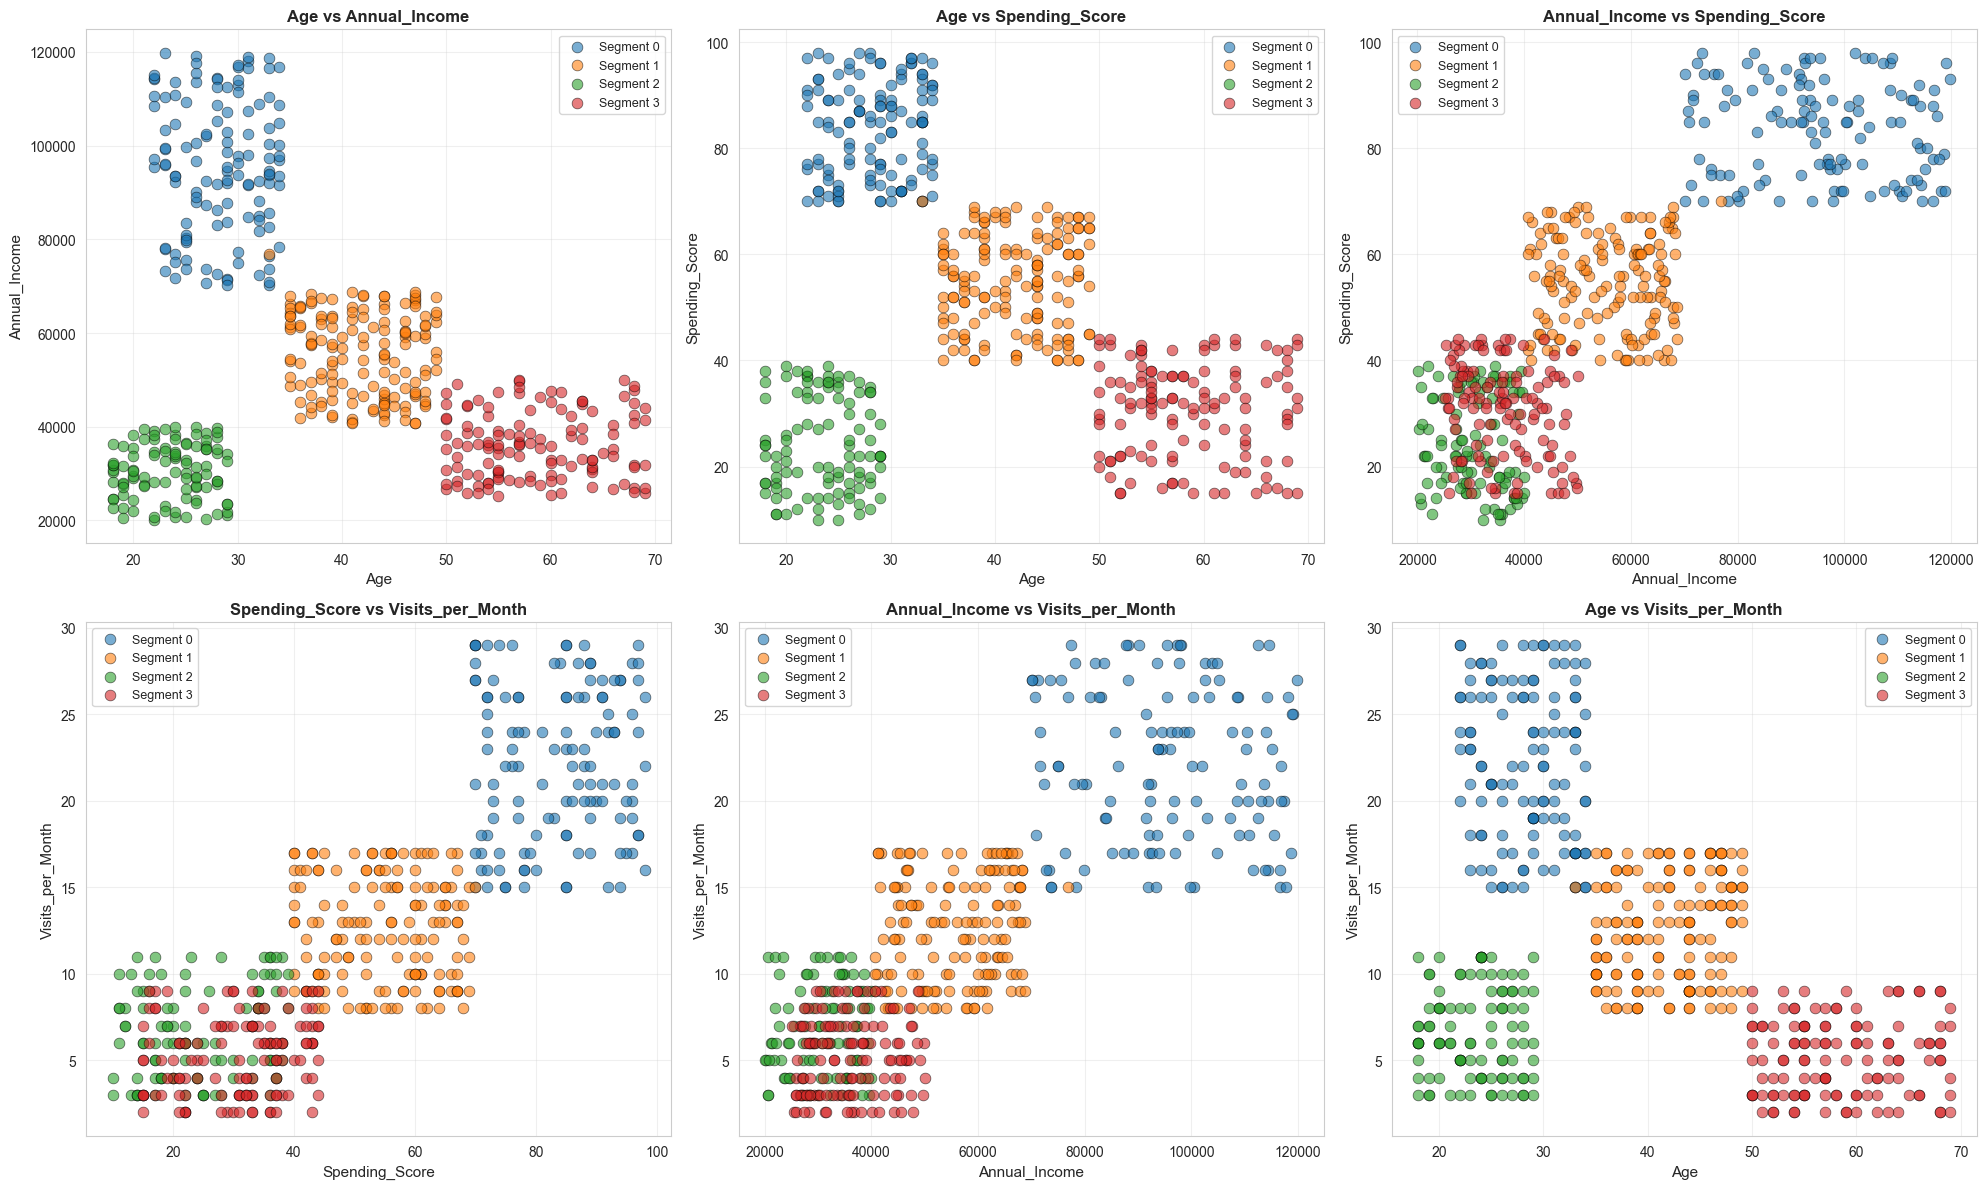

In [35]:
# Main visualization: 3x2 grid
fig, axes = plt.subplots(2, 3, figsize=(20, 12))

feature_pairs = [
    ('Age', 'Annual_Income'),
    ('Age', 'Spending_Score'),
    ('Annual_Income', 'Spending_Score'),
    ('Spending_Score', 'Visits_per_Month'),
    ('Annual_Income', 'Visits_per_Month'),
    ('Age', 'Visits_per_Month')
]

for idx, (feat1, feat2) in enumerate(feature_pairs):
    row = idx // 3
    col = idx % 3
    
    for segment in range(optimal_k_final):
        segment_data = mall_customer_data[mall_customer_data['Segment'] == segment]
        axes[row, col].scatter(segment_data[feat1], segment_data[feat2],
                              alpha=0.6, s=60, edgecolors='k', linewidth=0.5,
                              label=f'Segment {segment}')
    
    axes[row, col].set_xlabel(feat1, fontsize=11)
    axes[row, col].set_ylabel(feat2, fontsize=11)
    axes[row, col].set_title(f'{feat1} vs {feat2}', fontsize=12, fontweight='bold')
    axes[row, col].legend(fontsize=9)
    axes[row, col].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

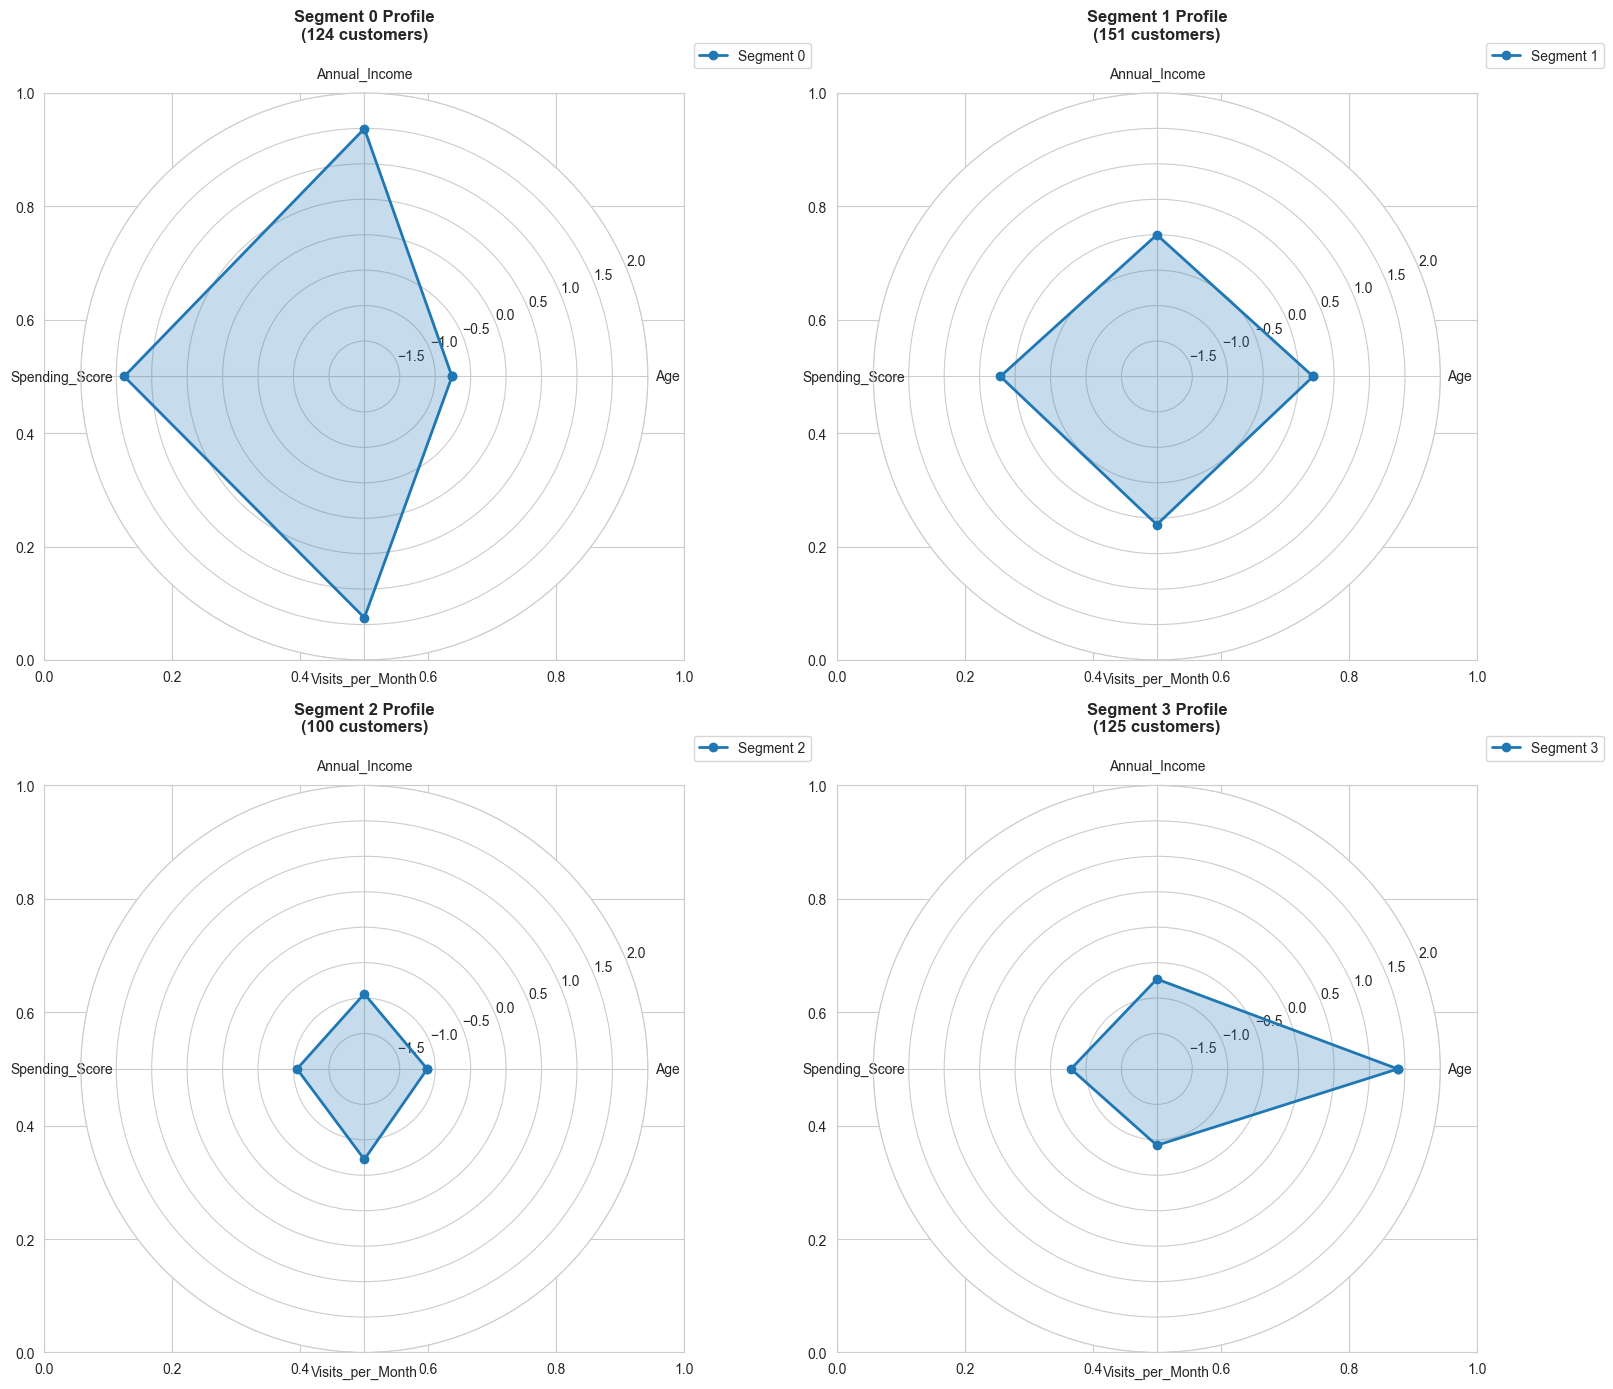

In [36]:
# Segment characteristics radar chart
fig, axes = plt.subplots(2, 2, figsize=(16, 14))

for segment in range(optimal_k_final):
    row = segment // 2
    col = segment % 2
    
    segment_data = mall_customer_data[mall_customer_data['Segment'] == segment]
    
    # Normalize values for radar chart
    values = []
    for feature in features_for_clustering:
        feature_mean = segment_data[feature].mean()
        overall_mean = mall_customer_data[feature].mean()
        overall_std = mall_customer_data[feature].std()
        normalized = (feature_mean - overall_mean) / overall_std
        values.append(normalized)
    
    values += values[:1]  # Close the radar chart
    
    angles = [n / float(len(features_for_clustering)) * 2 * np.pi 
             for n in range(len(features_for_clustering))]
    angles += angles[:1]
    
    ax = plt.subplot(2, 2, segment + 1, projection='polar')
    ax.plot(angles, values, 'o-', linewidth=2, label=f'Segment {segment}')
    ax.fill(angles, values, alpha=0.25)
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(features_for_clustering, fontsize=10)
    ax.set_ylim(-2, 2)
    ax.set_title(f'Segment {segment} Profile\n({len(segment_data)} customers)',
                fontsize=12, fontweight='bold', pad=20)
    ax.grid(True)
    ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))

plt.tight_layout()
plt.show()

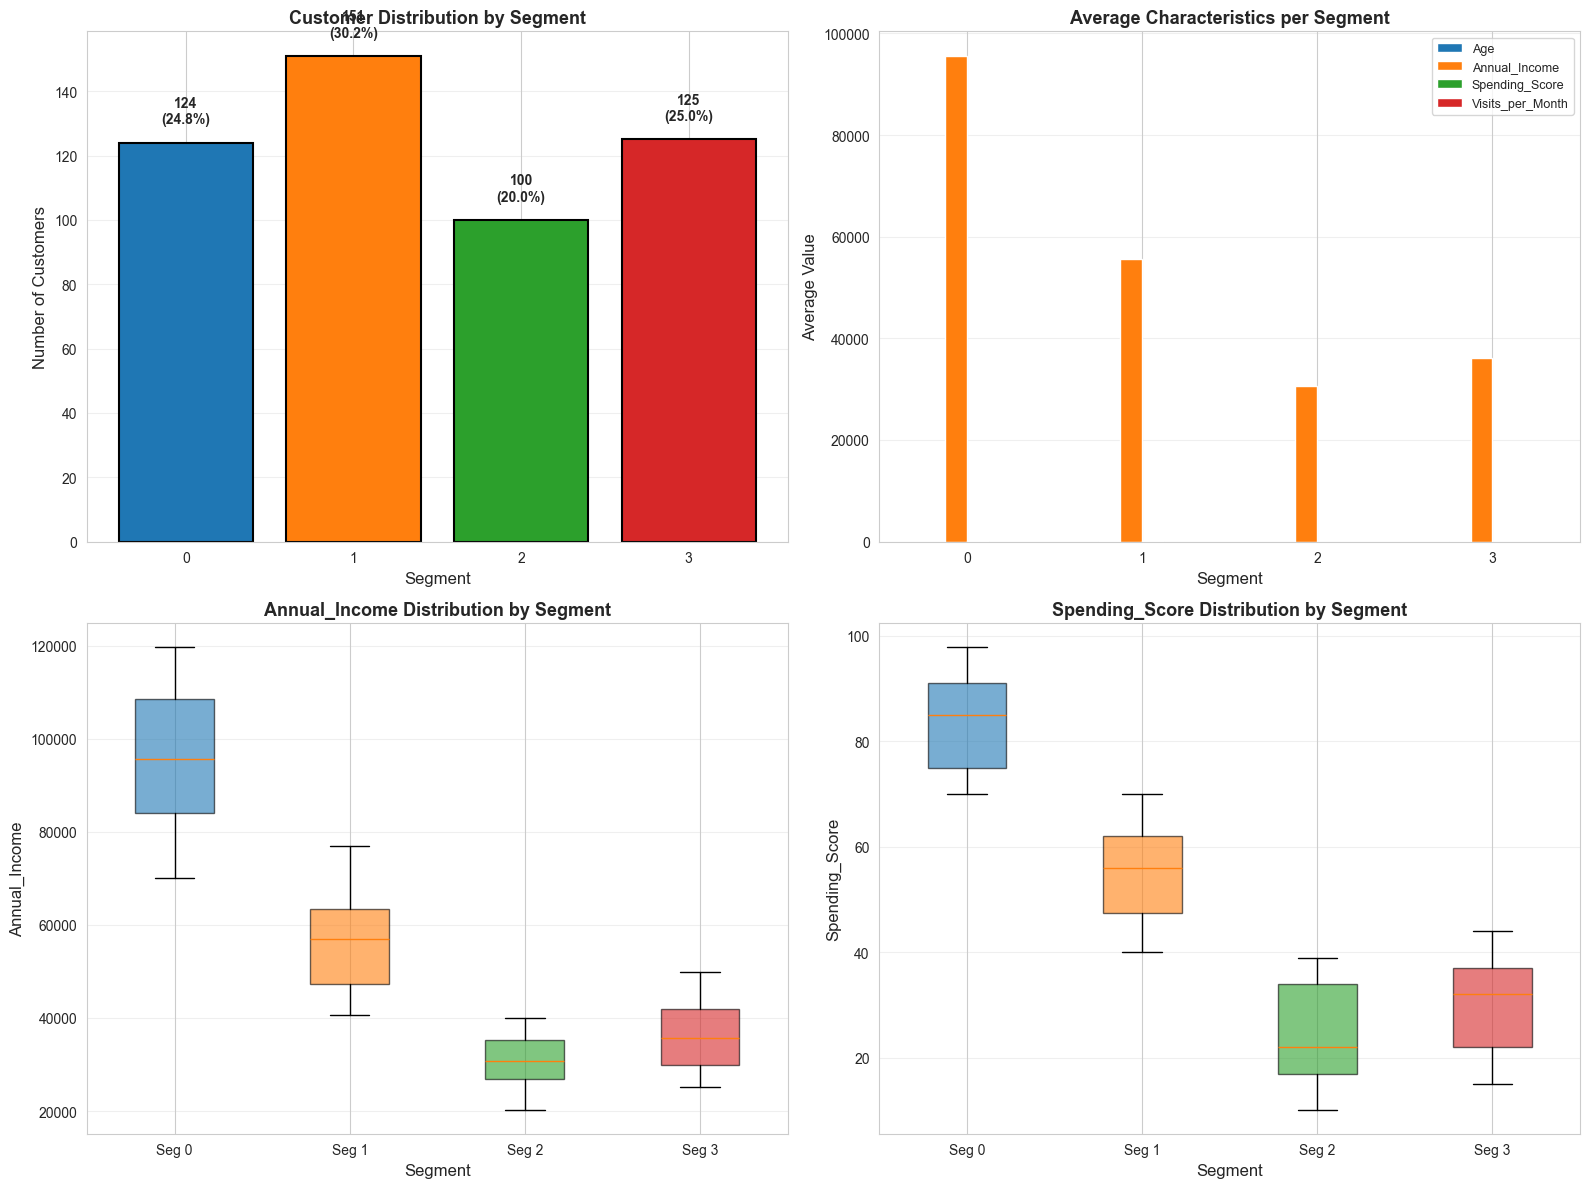

In [37]:
# Segment size and characteristics
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Segment sizes
segment_sizes = mall_customer_data['Segment'].value_counts().sort_index()
bars = axes[0, 0].bar(segment_sizes.index, segment_sizes.values, 
                      color=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728'],
                      edgecolor='black', linewidth=1.5)
axes[0, 0].set_xlabel('Segment', fontsize=12)
axes[0, 0].set_ylabel('Number of Customers', fontsize=12)
axes[0, 0].set_title('Customer Distribution by Segment', fontsize=13, fontweight='bold')
axes[0, 0].set_xticks(range(optimal_k_final))
axes[0, 0].grid(True, alpha=0.3, axis='y')
for bar, size in zip(bars, segment_sizes.values):
    axes[0, 0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                   f'{size}\n({size/len(mall_customer_data)*100:.1f}%)',
                   ha='center', va='bottom', fontsize=10, fontweight='bold')

# Average characteristics per segment
segment_summary.plot(kind='bar', ax=axes[0, 1], 
                    color=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728'])
axes[0, 1].set_xlabel('Segment', fontsize=12)
axes[0, 1].set_ylabel('Average Value', fontsize=12)
axes[0, 1].set_title('Average Characteristics per Segment', fontsize=13, fontweight='bold')
axes[0, 1].legend(fontsize=9, loc='upper right')
axes[0, 1].tick_params(axis='x', rotation=0)
axes[0, 1].grid(True, alpha=0.3, axis='y')

# Box plots for key metrics
for idx, feature in enumerate(['Annual_Income', 'Spending_Score']):
    ax = axes[1, idx]
    data_for_box = [mall_customer_data[mall_customer_data['Segment'] == seg][feature].values
                    for seg in range(optimal_k_final)]
    bp = ax.boxplot(data_for_box, labels=[f'Seg {i}' for i in range(optimal_k_final)],
                    patch_artist=True)
    
    colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.6)
    
    ax.set_xlabel('Segment', fontsize=12)
    ax.set_ylabel(feature, fontsize=12)
    ax.set_title(f'{feature} Distribution by Segment', fontsize=13, fontweight='bold')
    ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

### 9. Business Recommendations

In [38]:
# Analyze each segment
segment_names = []
segment_values = []
segment_strategies = []

for segment in range(optimal_k_final):
    segment_data = mall_customer_data[mall_customer_data['Segment'] == segment]
    
    avg_age = segment_data['Age'].mean()
    avg_income = segment_data['Annual_Income'].mean()
    avg_spending = segment_data['Spending_Score'].mean()
    avg_visits = segment_data['Visits_per_Month'].mean()
    size = len(segment_data)
    
    # Calculate value score
    value_score = (avg_spending * avg_visits * avg_income) / 1000000
    segment_values.append(value_score)
    
    # Determine segment name and strategy
    if avg_spending > 65 and avg_income > 65000:
        name = "Premium High-Value Customers"
        strategy = [
            "VIP membership programs with exclusive benefits",
            "Personalized shopping experiences and concierge services",
            "Early access to new products and sales",
            "Premium loyalty rewards (2x-3x points)",
            "Exclusive events and private shopping sessions"
        ]
    elif avg_spending > 50 and avg_visits > 12:
        name = "Loyal Frequent Shoppers"
        strategy = [
            "Frequency-based rewards and incentives",
            "Birthday and anniversary special offers",
            "Mobile app with personalized recommendations",
            "Tiered loyalty program to encourage more spending",
            "Community engagement through social media"
        ]
    elif avg_income > 50000 and avg_spending < 45:
        name = "Potential High-Value Customers"
        strategy = [
            "Targeted marketing showcasing value propositions",
            "Limited-time offers to increase engagement",
            "Cross-selling and upselling campaigns",
            "Educational content about product benefits",
            "Referral programs with attractive incentives"
        ]
    else:
        name = "Price-Conscious Shoppers"
        strategy = [
            "Regular promotions and discount campaigns",
            "Budget-friendly product lines",
            "Seasonal clearance sales",
            "Email marketing with special deals",
            "Entry-level loyalty program"
        ]
    
    segment_names.append(name)
    segment_strategies.append(strategy)
    
    print(f"\n{'='*80}")
    print(f"SEGMENT {segment}: {name.upper()}")
    print(f"{'='*80}")
    print(f"")
    print(f"CHARACTERISTICS:")
    print(f"• Size: {size} customers ({size/len(mall_customer_data)*100:.1f}% of total)")
    print(f"• Average Age: {avg_age:.1f} years")
    print(f"• Average Annual Income: ${avg_income:,.0f}")
    print(f"• Average Spending Score: {avg_spending:.1f}/100")
    print(f"• Average Visits per Month: {avg_visits:.1f}")
    print(f"• Customer Lifetime Value Score: {value_score:.2f}")
    print(f"")
    print(f"MARKETING STRATEGIES:")
    for i, strat in enumerate(strategy, 1):
        print(f"{i}. {strat}")


SEGMENT 0: PREMIUM HIGH-VALUE CUSTOMERS

CHARACTERISTICS:
• Size: 124 customers (24.8% of total)
• Average Age: 28.4 years
• Average Annual Income: $95,622
• Average Spending Score: 83.6/100
• Average Visits per Month: 22.1
• Customer Lifetime Value Score: 176.88

MARKETING STRATEGIES:
1. VIP membership programs with exclusive benefits
2. Personalized shopping experiences and concierge services
3. Early access to new products and sales
4. Premium loyalty rewards (2x-3x points)
5. Exclusive events and private shopping sessions

SEGMENT 1: LOYAL FREQUENT SHOPPERS

CHARACTERISTICS:
• Size: 151 customers (30.2% of total)
• Average Age: 41.9 years
• Average Annual Income: $55,622
• Average Spending Score: 54.8/100
• Average Visits per Month: 12.6
• Customer Lifetime Value Score: 38.29

MARKETING STRATEGIES:
1. Frequency-based rewards and incentives
2. Birthday and anniversary special offers
3. Mobile app with personalized recommendations
4. Tiered loyalty program to encourage more spending

In [39]:
# Most valuable segment
most_valuable_segment = np.argmax(segment_values)
print(f"\n{'='*80}")
print(f"MOST VALUABLE SEGMENT: Segment {most_valuable_segment} - {segment_names[most_valuable_segment]}")
print(f"{'='*80}")
print(f"• Highest customer lifetime value score: {segment_values[most_valuable_segment]:.2f}")
print(f"• Primary revenue driver for the business")
print(f"• Should receive highest priority in resource allocation")
print(f"• Focus on retention and satisfaction programs")

# Segment needing attention
segment_visits = [mall_customer_data[mall_customer_data['Segment'] == s]['Visits_per_Month'].mean() 
                 for s in range(optimal_k_final)]
segment_spending = [mall_customer_data[mall_customer_data['Segment'] == s]['Spending_Score'].mean() 
                   for s in range(optimal_k_final)]
attention_scores = [v * s for v, s in zip(segment_visits, segment_spending)]
needs_attention_segment = np.argmin(attention_scores)

print(f"\n{'='*80}")
print(f"SEGMENT NEEDING ATTENTION: Segment {needs_attention_segment} - {segment_names[needs_attention_segment]}")
print(f"{'='*80}")
print(f"• Lowest engagement and spending combination")
print(f"• Risk of churn or disengagement")
print(f"• Requires targeted re-engagement campaigns")
print(f"• Potential for growth with right incentives")


MOST VALUABLE SEGMENT: Segment 0 - Premium High-Value Customers
• Highest customer lifetime value score: 176.88
• Primary revenue driver for the business
• Should receive highest priority in resource allocation
• Focus on retention and satisfaction programs

SEGMENT NEEDING ATTENTION: Segment 3 - Price-Conscious Shoppers
• Lowest engagement and spending combination
• Risk of churn or disengagement
• Requires targeted re-engagement campaigns
• Potential for growth with right incentives


In [40]:
# Overall recommendations
print(f"\n{'='*80}")
print(f"OVERALL BUSINESS RECOMMENDATIONS:")
print(f"{'='*80}")
print(f"")
print(f"1. RESOURCE ALLOCATION:")
print(f"   • Allocate 40% of marketing budget to Segment {most_valuable_segment} (highest value)")
print(f"   • Allocate 30% to growth segments with high potential")
print(f"   • Allocate 20% to retention programs for frequent shoppers")
print(f"   • Allocate 10% to re-engagement for low-activity segments")
print(f"")
print(f"2. DIFFERENTIATED PRICING STRATEGY:")
print(f"   • Premium pricing with added value for high-income segments")
print(f"   • Volume discounts for frequent shoppers")
print(f"   • Promotional pricing for price-sensitive segments")
print(f"   • Dynamic pricing based on segment characteristics")
print(f"")
print(f"3. PERSONALIZATION:")
print(f"   • Implement segment-based email marketing campaigns")
print(f"   • Customize website experience based on customer segment")
print(f"   • Personalized product recommendations")
print(f"   • Tailored loyalty program benefits per segment")
print(f"")
print(f"4. GROWTH STRATEGY:")
print(f"   • Focus on converting Segment {needs_attention_segment} to higher-value segments")
print(f"   • Develop upselling paths between segments")
print(f"   • Create segment-specific acquisition campaigns")
print(f"   • Monitor segment migration patterns monthly")
print(f"")
print(f"5. RETENTION FOCUS:")
print(f"   • Implement early warning system for segment migration")
print(f"   • Regular satisfaction surveys per segment")
print(f"   • Proactive customer service for high-value segments")
print(f"   • Win-back campaigns for declining customers")
print(f"\n{'='*80}")


OVERALL BUSINESS RECOMMENDATIONS:

1. RESOURCE ALLOCATION:
   • Allocate 40% of marketing budget to Segment 0 (highest value)
   • Allocate 30% to growth segments with high potential
   • Allocate 20% to retention programs for frequent shoppers
   • Allocate 10% to re-engagement for low-activity segments

2. DIFFERENTIATED PRICING STRATEGY:
   • Premium pricing with added value for high-income segments
   • Volume discounts for frequent shoppers
   • Promotional pricing for price-sensitive segments
   • Dynamic pricing based on segment characteristics

3. PERSONALIZATION:
   • Implement segment-based email marketing campaigns
   • Customize website experience based on customer segment
   • Personalized product recommendations
   • Tailored loyalty program benefits per segment

4. GROWTH STRATEGY:
   • Focus on converting Segment 3 to higher-value segments
   • Develop upselling paths between segments
   • Create segment-specific acquisition campaigns
   • Monitor segment migration pat

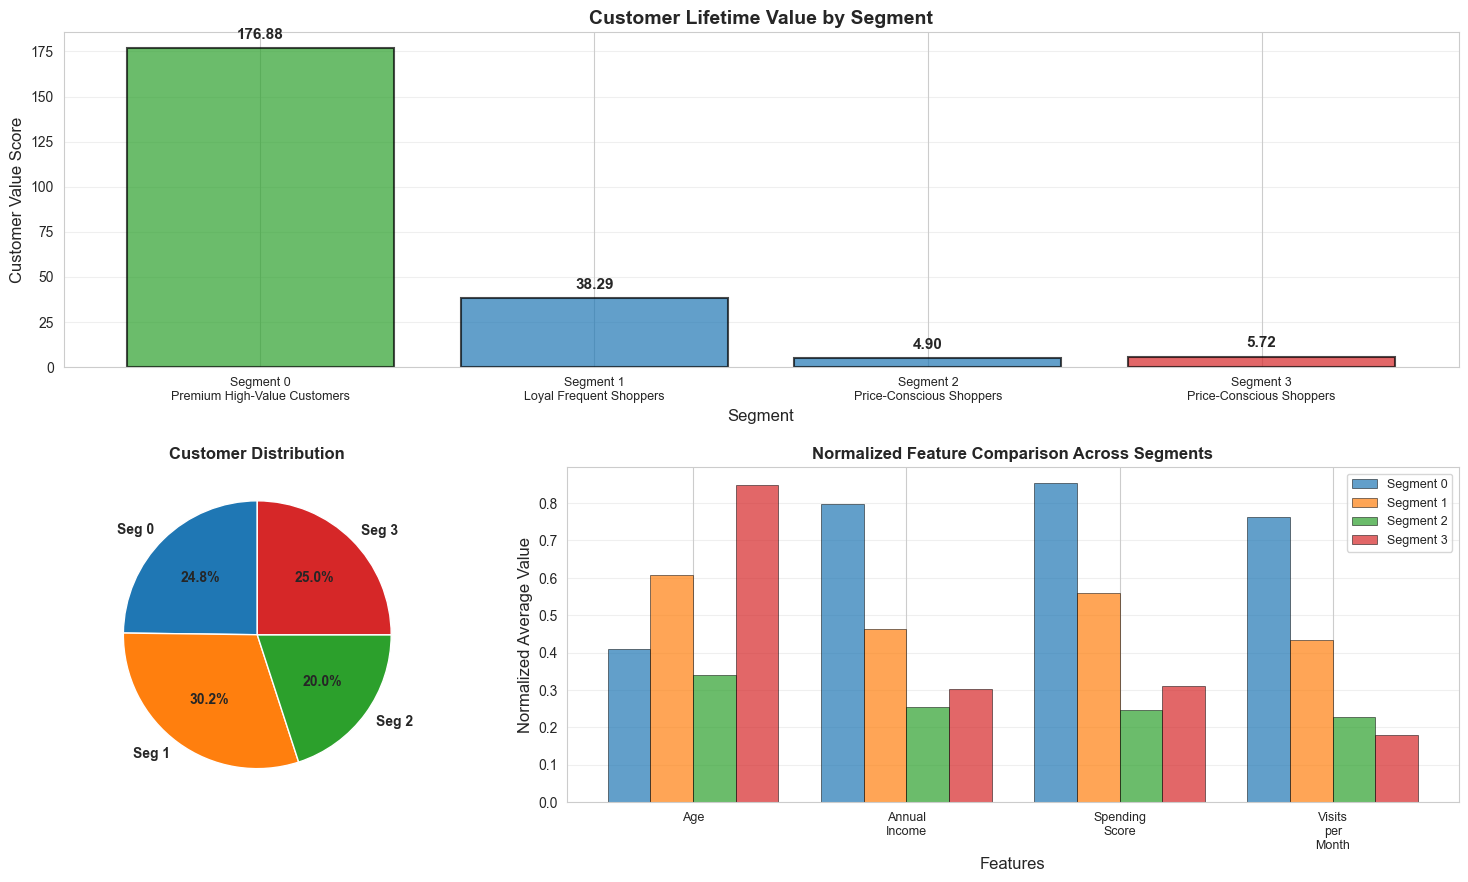

In [41]:
# Create summary visualization
fig = plt.figure(figsize=(18, 10))
gs = fig.add_gridspec(2, 3, hspace=0.3, wspace=0.3)

# Segment value comparison
ax1 = fig.add_subplot(gs[0, :])
colors_value = ['#2ca02c' if i == most_valuable_segment else 
               '#d62728' if i == needs_attention_segment else 
               '#1f77b4' for i in range(optimal_k_final)]
bars = ax1.bar(range(optimal_k_final), segment_values, color=colors_value, 
              edgecolor='black', linewidth=1.5, alpha=0.7)
ax1.set_xlabel('Segment', fontsize=12)
ax1.set_ylabel('Customer Value Score', fontsize=12)
ax1.set_title('Customer Lifetime Value by Segment', fontsize=14, fontweight='bold')
ax1.set_xticks(range(optimal_k_final))
ax1.set_xticklabels([f'Segment {i}\n{segment_names[i]}' for i in range(optimal_k_final)], 
                    fontsize=9)
ax1.grid(True, alpha=0.3, axis='y')
for bar, value in zip(bars, segment_values):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(segment_values)*0.02,
            f'{value:.2f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

# Segment sizes pie chart
ax2 = fig.add_subplot(gs[1, 0])
segment_sizes = mall_customer_data['Segment'].value_counts().sort_index()
colors_pie = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']
wedges, texts, autotexts = ax2.pie(segment_sizes.values, labels=[f'Seg {i}' for i in range(optimal_k_final)],
                                    autopct='%1.1f%%', colors=colors_pie, startangle=90,
                                    textprops={'fontsize': 10, 'weight': 'bold'})
ax2.set_title('Customer Distribution', fontsize=12, fontweight='bold')

# Average metrics comparison
ax3 = fig.add_subplot(gs[1, 1:])
x = np.arange(len(features_for_clustering))
width = 0.2

for i in range(optimal_k_final):
    segment_data = mall_customer_data[mall_customer_data['Segment'] == i]
    means = [segment_data[feat].mean() / mall_customer_data[feat].max() 
            for feat in features_for_clustering]
    ax3.bar(x + i*width, means, width, label=f'Segment {i}', 
           color=colors_pie[i], edgecolor='black', linewidth=0.5, alpha=0.7)

ax3.set_xlabel('Features', fontsize=12)
ax3.set_ylabel('Normalized Average Value', fontsize=12)
ax3.set_title('Normalized Feature Comparison Across Segments', fontsize=12, fontweight='bold')
ax3.set_xticks(x + width * 1.5)
ax3.set_xticklabels([f.replace('_', '\n') for f in features_for_clustering], fontsize=9)
ax3.legend(fontsize=9, loc='upper right')
ax3.grid(True, alpha=0.3, axis='y')

plt.show()